### author by yangshichen
### 注意：脚本仅供参考，使用前请仔细阅读

In [1]:
library(ggplot2)
library(future)
library(tidyverse)
library(ggpubr)
library(ggchicklet)
library(ggsci)
library(magrittr)
library(ggh4x)
library(rstatix)
library(ggsignif)
library(ggnewscale)
library(patchwork)
library(gapminder)
library(ggprism)
library(dplyr)
library(ggplotify)
library(readr)
library(arrow)
library(ggbreak)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

载入程序包：‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract



载入程序包：‘rstatix’


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘arrow’


The following object is masked from ‘package:magrittr’:

    is_in


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked from ‘package:utils’:

    timestamp


ggbreak v0.1.5 Learn more 

In [2]:
mytheme <- theme_prism(base_family="",base_fontface="plain") +
  theme(strip.text = element_text(size = 8,angle=10,vjust = 0.5,hjust = 0.5),
        axis.line = element_line(color = "black",size = 0.2),
        axis.ticks = element_line(size = 0.2),
        axis.text.y = element_text(color = "black",size = 6),
        axis.text.x = element_text(color = "black",size = 6, angle = 30,hjust = 1,vjust = 1),
        axis.title = element_text(color = "black",size = 10),
        legend.position = "none")

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


### eQTL

#### permutations eGene统计

In [3]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues.csv",check.names = F,header = T))
data

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,celltype_level_pval_nominal_threshold,study_wise_qval,study_wise_nominal_threshold
<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,LINC01409,2098,1.014873,175.4605,633.2236,7.667730e-06,1:913469:G:C,134721,103404,⋯,1.174355e-06,0.3765205,0.07683704,0.00119988,1.210901e-03,Adaptive NK cells,1.590819e-03,0.0003445664,3.700370e-03,1.377503e-04
1,LINC00115,2110,1.034240,184.2302,638.6180,1.084343e-18,1:913469:G:C,89240,85930,⋯,1.345368e-21,0.7540356,0.07656465,0.00009999,5.709014e-17,Adaptive NK cells,2.350422e-16,0.0003494642,5.632009e-16,1.419710e-04
2,LINC01128,2155,1.033578,190.2563,638.3401,2.224656e-33,1:913469:G:C,88330,54023,⋯,8.960126e-39,0.9652224,0.06992146,0.00009999,3.985215e-32,Adaptive NK cells,3.243837e-31,0.0003376822,7.682978e-31,1.371101e-04
3,NOC2L,2384,1.032902,223.7807,655.3950,4.551931e-03,1:958082:C:T,13878,-1227,⋯,2.453030e-03,0.1181186,0.03886217,0.62963704,6.257363e-01,Adaptive NK cells,2.932454e-01,0.0002864857,4.563781e-01,1.162568e-04
4,KLHL17,2403,1.024781,203.5820,645.1254,8.818563e-04,1:920661:G:A,-39924,-45058,⋯,3.450516e-04,-0.2284575,0.06353982,0.15738426,1.557183e-01,Adaptive NK cells,1.131552e-01,0.0003067665,2.141821e-01,1.236591e-04
5,PLEKHN1,2442,1.012655,203.7439,639.7712,9.955614e-06,1:967724:C:T,1241,-8141,⋯,1.803183e-06,0.2515789,0.05227502,0.00119988,1.863383e-03,Adaptive NK cells,2.363903e-03,0.0002945747,5.501332e-03,1.175416e-04
6,HES4,2544,1.040256,206.6732,632.9800,3.134341e-16,1:1000079:A:G,1116,-93,⋯,7.069647e-19,0.5806572,0.06369613,0.00009999,1.874707e-14,Adaptive NK cells,6.650379e-14,0.0003175379,1.603061e-13,1.296284e-04
7,ISG15,2579,1.031593,217.5914,637.3262,1.278423e-08,1:1015903:C:T,14764,1363,⋯,7.304698e-10,0.1901433,0.03046918,0.00009999,1.831833e-06,Adaptive NK cells,3.476263e-06,0.0002933993,8.237876e-06,1.189355e-04
8,AGRN,2655,1.018641,233.6488,639.6821,1.074286e-03,1:820395:A:G,-199726,-235723,⋯,4.090022e-04,-0.2078456,0.05854430,0.21737826,2.144721e-01,Adaptive NK cells,1.432669e-01,0.0002619972,2.612492e-01,1.050714e-04


In [4]:
sub_data <- subset(data, study_wise_qval < 0.05)
sub_data

,,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,celltype_level_pval_nominal_threshold,study_wise_qval,study_wise_nominal_threshold
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,LINC01409,2098,1.014873,175.4605,633.2236,7.667730e-06,1:913469:G:C,134721,103404,⋯,1.174355e-06,0.3765205,0.07683704,0.00119988,1.210901e-03,Adaptive NK cells,1.590819e-03,0.0003445664,3.700370e-03,1.377503e-04
2,1,LINC00115,2110,1.034240,184.2302,638.6180,1.084343e-18,1:913469:G:C,89240,85930,⋯,1.345368e-21,0.7540356,0.07656465,0.00009999,5.709014e-17,Adaptive NK cells,2.350422e-16,0.0003494642,5.632009e-16,1.419710e-04
3,2,LINC01128,2155,1.033578,190.2563,638.3401,2.224656e-33,1:913469:G:C,88330,54023,⋯,8.960126e-39,0.9652224,0.06992146,0.00009999,3.985215e-32,Adaptive NK cells,3.243837e-31,0.0003376822,7.682978e-31,1.371101e-04
6,5,PLEKHN1,2442,1.012655,203.7439,639.7712,9.955614e-06,1:967724:C:T,1241,-8141,⋯,1.803183e-06,0.2515789,0.05227502,0.00119988,1.863383e-03,Adaptive NK cells,2.363903e-03,0.0002945747,5.501332e-03,1.175416e-04
7,6,HES4,2544,1.040256,206.6732,632.9800,3.134341e-16,1:1000079:A:G,1116,-93,⋯,7.069647e-19,0.5806572,0.06369613,0.00009999,1.874707e-14,Adaptive NK cells,6.650379e-14,0.0003175379,1.603061e-13,1.296284e-04
8,7,ISG15,2579,1.031593,217.5914,637.3262,1.278423e-08,1:1015903:C:T,14764,1363,⋯,7.304698e-10,0.1901433,0.03046918,0.00009999,1.831833e-06,Adaptive NK cells,3.476263e-06,0.0002933993,8.237876e-06,1.189355e-04
10,9,C1orf159,2845,1.009523,256.2610,654.2985,9.117941e-05,1:1023789:G:C,-58030,-92572,⋯,2.900352e-05,-0.2388179,0.05676469,0.02209779,2.219327e-02,Adaptive NK cells,2.243731e-02,0.0002317901,4.951678e-02,9.224086e-05
11,10,TNFRSF18,2898,1.040453,221.8812,634.2929,4.812934e-52,1:1217733:G:A,14224,11141,⋯,5.615811e-61,-0.7218388,0.03988647,0.00009999,1.096144e-51,Adaptive NK cells,1.675139e-50,0.0002959626,3.933917e-50,1.208391e-04
12,11,TNFRSF4,2913,1.052444,212.6466,626.4841,1.036046e-44,1:1217251:C:A,5924,3098,⋯,5.620543e-53,-0.6538712,0.03936067,0.00009999,1.407439e-44,Adaptive NK cells,1.746132e-43,0.0003206232,4.087194e-43,1.321603e-04


In [5]:
length(unique(sub_data$phenotype_id))

[1] 12198

In [6]:
write.csv(sub_data,'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv')

#### plot 1

In [2]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv",check.names = F,header = T))

In [3]:
length(unique(data$phenotype_id))

[1] 12198

In [4]:
subdata1 <- subset(data, celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                            'Proliferative mLDNs'))
length(unique(subdata1$phenotype_id))

[1] 8047

In [24]:
subdata1

,,.1,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,⋯,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,celltype_level_pval_nominal_threshold,study_wise_qval,study_wise_nominal_threshold
,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
4571,11850,11849,LINC01409,2104,1.017751,179.9772,660.4215,1.111952e-04,1:807692:C:A,28944,⋯,2.761931e-05,0.24266766,0.05753903,0.01589841,1.834494e-02,ALPL- MARCKS- NDNs,1.949730e-02,0.0003313612,4.216210e-02,1.359016e-04
4572,11851,11850,LINC00115,2116,1.044348,192.1801,669.2017,1.029211e-13,1:913469:G:C,89240,⋯,1.108950e-15,0.58634245,0.07163288,0.00009999,6.503583e-12,ALPL- MARCKS- NDNs,1.803160e-11,0.0003381793,4.697923e-11,1.416751e-04
4573,11852,11851,LINC01128,2161,1.032983,190.6274,664.2394,4.061863e-26,1:844849:T:C,19710,⋯,2.837183e-30,0.73334600,0.06143962,0.00009999,1.319692e-24,ALPL- MARCKS- NDNs,6.669657e-24,0.0003287920,1.889775e-23,1.365169e-04
4574,11856,11855,HES4,2549,1.029389,219.9180,668.8524,7.597904e-34,1:1000079:A:G,1116,⋯,4.799471e-39,0.54187340,0.03918425,0.00009999,2.055712e-32,ALPL- MARCKS- NDNs,1.363022e-31,0.0002817199,4.001455e-31,1.166356e-04
4575,11857,11856,ISG15,2584,1.047945,221.1552,662.7006,3.119217e-10,1:1015297:T:C,14158,⋯,9.478632e-12,0.07648542,0.01105349,0.00009999,3.064259e-08,ALPL- MARCKS- NDNs,6.532701e-08,0.0002972326,1.644055e-07,1.248669e-04
4576,11862,11861,B3GALT6,2949,1.034600,220.4002,655.7380,4.313021e-05,1:1189439:C:T,-42799,⋯,8.489825e-06,-0.22530840,0.05026453,0.00689931,7.933417e-03,ALPL- MARCKS- NDNs,9.132359e-03,0.0002858697,2.036573e-02,1.188462e-04
4577,11863,11862,UBE2J2,3008,1.038696,233.1927,662.3993,6.365058e-14,1:1274256:A:G,20346,⋯,4.520515e-16,-0.30614328,0.03687544,0.00009999,5.561951e-12,ALPL- MARCKS- NDNs,1.550015e-11,0.0002737572,4.036870e-11,1.141787e-04
4578,11865,11864,PUSL1,3079,1.044422,231.6580,653.2805,1.607569e-11,1:1368177:G:C,59579,⋯,2.002141e-13,0.40556204,0.05421457,0.00009999,1.542400e-09,ALPL- MARCKS- NDNs,3.670853e-09,0.0002806274,9.296717e-09,1.175694e-04
4579,11869,11868,AURKAIP1,3294,1.032484,272.9642,669.0287,3.329424e-05,1:1398218:C:A,24487,⋯,7.740457e-06,-0.24149930,0.05363506,0.00589941,7.657323e-03,ALPL- MARCKS- NDNs,8.854499e-03,0.0002292637,1.973815e-02,9.515150e-05


In [34]:
library(dplyr)

result <- subdata1[, c("phenotype_id", "celltype")] %>%
  group_by(phenotype_id) %>%
  summarise(n_celltype = n_distinct(celltype)) %>%
  mutate(
    share_group = case_when(
      n_celltype == 1 ~ "1",
      n_celltype >= 2 & n_celltype <= 5 ~ as.character(n_celltype),
      n_celltype >= 6 ~ ">=6"
    )
  ) %>%
  count(share_group)

result

share_group,n
<chr>,<int>
1,2736
2,891
3,511
4,388
5,368
>=6,3153


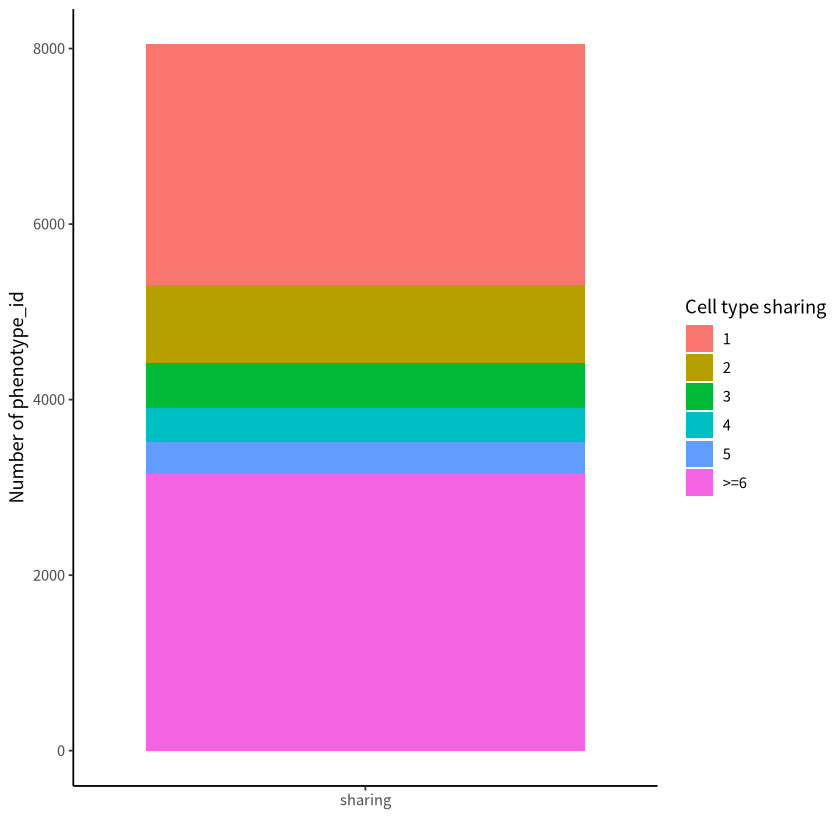

In [39]:
result$share_group <- factor(
  result$share_group,
  levels = c(as.character(1:5), ">=6")
)
p <- ggplot(result, aes(x = "sharing", y = n, fill = share_group)) +
  geom_bar(stat = "identity") +
  labs(x = "", y = "Number of phenotype_id", fill = "Cell type sharing") +
  theme_classic()
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/neu_egene_ratio.pdf",p,width=15,height=3)

In [5]:
subdata2 <- subset(data, celltype %in% c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                                            'LAMP3+ DC'))
length(unique(subdata2$phenotype_id))

[1] 11435

In [41]:
library(dplyr)

result <- subdata2[, c("phenotype_id", "celltype")] %>%
  group_by(phenotype_id) %>%
  summarise(n_celltype = n_distinct(celltype)) %>%
  mutate(
    share_group = case_when(
      n_celltype == 1 ~ "1",
      n_celltype >= 2 & n_celltype <= 9 ~ as.character(n_celltype),
      n_celltype >= 10 ~ ">=10"
    )
  ) %>%
  count(share_group)

result

share_group,n
<chr>,<int>
1,2245
2,1554
3,1021
4,779
5,615
6,532
7,446
8,380
9,347


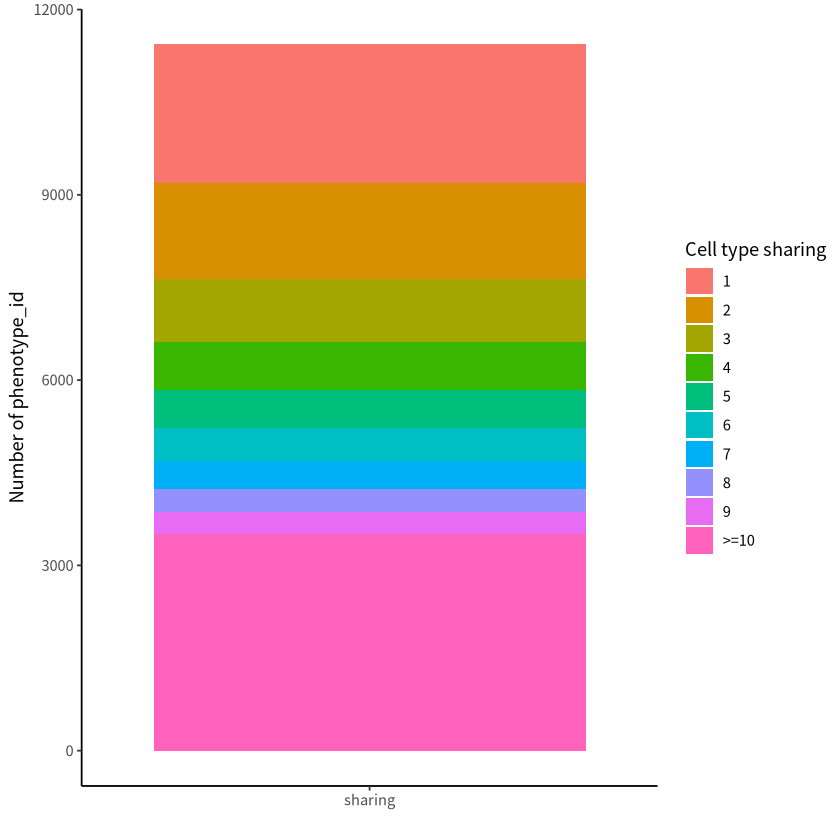

In [42]:
result$share_group <- factor(
  result$share_group,
  levels = c(as.character(1:9), ">=10")
)
p <- ggplot(result, aes(x = "sharing", y = n, fill = share_group)) +
  geom_bar(stat = "identity") +
  labs(x = "", y = "Number of phenotype_id", fill = "Cell type sharing") +
  theme_classic()
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/pbmc_egene_ratio.pdf",p,width=15,height=3)

In [6]:
# 每个 phenotype_id 出现在哪些 celltype
pheno_cell_map <- data %>%
  distinct(celltype, phenotype_id) %>%
  group_by(phenotype_id) %>%
  summarise(celltype_count = n(),
            celltypes = paste(sort(unique(celltype)), collapse = ",")) %>%
  ungroup()

In [7]:
# 特有的 phenotype_id
unique_phenos <- pheno_cell_map %>%
  filter(celltype_count == 1)

# 共享的 phenotype_id
shared_phenos <- pheno_cell_map %>%
  filter(celltype_count > 1)

In [9]:
# 合并 celltype 到 pheno 表
df_pheno_info <- data %>%
  distinct(celltype, phenotype_id) %>%
  left_join(pheno_cell_map, by = "phenotype_id")

# 每个 celltype 的统计
tmp <- df_pheno_info %>% group_by(celltype) %>%
       summarise(unique_phenotype_n = sum(celltype_count == 1),
                 shared_phenotype_n = sum(celltype_count > 1))
tmp$total_egenes <- tmp$unique_phenotype_n + tmp$shared_phenotype_n
colnames(tmp) <- c('celltype','unique_egenes','shared_egenes','total_egenes')
tmp$celltype <- factor(tmp$celltype,levels = c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP','LAMP3+ DC','Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                               'Proliferative mLDNs'))
tmp

celltype,unique_egenes,shared_egenes,total_egenes
<fct>,<int>,<int>,<int>
ALPL- MARCKS- NDNs,15,4182,4197
ASDC,0,140,140
Adaptive NK cells,52,4518,4570
Atypical naïve B cells,2,72,74
Basophils,8,163,171
CCR4+ CD8+ Tcm,11,893,904
CCR4- CD8+ Tcm,6,294,300
CD14+ cDC2,16,1851,1867
CD177int iLDNs,1,45,46


In [10]:
tmp_long <- tmp %>%
  pivot_longer(cols = c(unique_egenes, shared_egenes),
               names_to = "type",
               values_to = "count") %>%
  mutate(type = recode(type,
                       shared_egenes = "Shared eGenes",
                       unique_egenes = "Unique eGenes"))
tmp_long$type <- factor(tmp_long$type, levels = c('Unique eGenes','Shared eGenes'))
tmp_long

celltype,total_egenes,type,count
<fct>,<int>,<fct>,<int>
ALPL- MARCKS- NDNs,4197,Unique eGenes,15
ALPL- MARCKS- NDNs,4197,Shared eGenes,4182
ASDC,140,Unique eGenes,0
ASDC,140,Shared eGenes,140
Adaptive NK cells,4570,Unique eGenes,52
Adaptive NK cells,4570,Shared eGenes,4518
Atypical naïve B cells,74,Unique eGenes,2
Atypical naïve B cells,74,Shared eGenes,72
Basophils,171,Unique eGenes,8


In [11]:
tmp_long_plot <- tmp_long %>%
  group_by(celltype) %>%
  mutate(
    total_log = log10(first(total_egenes)),  # 总数取log10
    prop = count / total_egenes,             # 各类型比例
    height = total_log * prop                # 按比例分配高度
  )
tmp_long_plot

celltype,total_egenes,type,count,total_log,prop,height
<fct>,<int>,<fct>,<int>,<dbl>,<dbl>,<dbl>
ALPL- MARCKS- NDNs,4197,Unique eGenes,15,3.622939,0.003573981,0.01294832
ALPL- MARCKS- NDNs,4197,Shared eGenes,4182,3.622939,0.996426019,3.60999065
ASDC,140,Unique eGenes,0,2.146128,0.000000000,0.00000000
ASDC,140,Shared eGenes,140,2.146128,1.000000000,2.14612804
Adaptive NK cells,4570,Unique eGenes,52,3.659916,0.011378556,0.04164456
Adaptive NK cells,4570,Shared eGenes,4518,3.659916,0.988621444,3.61827164
Atypical naïve B cells,74,Unique eGenes,2,1.869232,0.027027027,0.05051978
Atypical naïve B cells,74,Shared eGenes,72,1.869232,0.972972973,1.81871194
Basophils,171,Unique eGenes,8,2.232996,0.046783626,0.10446765


In [12]:
tmp_long_plot1 <- subset(tmp_long_plot, celltype %in% c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                                                        'LAMP3+ DC'))
tmp_long_plot1

celltype,total_egenes,type,count,total_log,prop,height
<fct>,<int>,<fct>,<int>,<dbl>,<dbl>,<dbl>
ASDC,140,Unique eGenes,0,2.146128,0.000000000,0.00000000
ASDC,140,Shared eGenes,140,2.146128,1.000000000,2.14612804
Adaptive NK cells,4570,Unique eGenes,52,3.659916,0.011378556,0.04164456
Adaptive NK cells,4570,Shared eGenes,4518,3.659916,0.988621444,3.61827164
Atypical naïve B cells,74,Unique eGenes,2,1.869232,0.027027027,0.05051978
Atypical naïve B cells,74,Shared eGenes,72,1.869232,0.972972973,1.81871194
CCR4+ CD8+ Tcm,904,Unique eGenes,11,2.956168,0.012168142,0.03597108
CCR4+ CD8+ Tcm,904,Shared eGenes,893,2.956168,0.987831858,2.92019735
CCR4- CD8+ Tcm,300,Unique eGenes,6,2.477121,0.020000000,0.04954243


In [13]:
tmp_long_plot2 <- subset(tmp_long_plot, celltype %in% c('Basophils','ALPL- MARCKS- NDNs','Core NDNs','CXCL8- PTGS2+ NDNs','FOS- NDNs','IFIT2- RNF213- NDNs','IRF1- GBP2- NDNs','MT-ATP6- MT-CO2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs'))
tmp_long_plot2

celltype,total_egenes,type,count,total_log,prop,height
<fct>,<int>,<fct>,<int>,<dbl>,<dbl>,<dbl>
ALPL- MARCKS- NDNs,4197,Unique eGenes,15,3.622939,0.003573981,0.01294832
ALPL- MARCKS- NDNs,4197,Shared eGenes,4182,3.622939,0.996426019,3.60999065
Basophils,171,Unique eGenes,8,2.232996,0.046783626,0.10446765
Basophils,171,Shared eGenes,163,2.232996,0.953216374,2.12852846
CXCL8- PTGS2+ NDNs,2908,Unique eGenes,12,3.463594,0.004126547,0.01429269
CXCL8- PTGS2+ NDNs,2908,Shared eGenes,2896,3.463594,0.995873453,3.44930172
Core NDNs,6908,Unique eGenes,326,3.839352,0.047191662,0.18118542
Core NDNs,6908,Shared eGenes,6582,3.839352,0.952808338,3.65816691
FOS- NDNs,2957,Unique eGenes,16,3.470851,0.005410889,0.01878039


In [14]:
tmp_long_plot3 <- subset(tmp_long_plot, celltype %in% c('CD177int iLDNs','MMP8+ CD177+ iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO- CD177- iLDNs','MPO+ CD177- iLDNs','MPO+ mLDNs','Proliferative iLDNs','Proliferative mLDNs'))
tmp_long_plot3

celltype,total_egenes,type,count,total_log,prop,height
<fct>,<int>,<fct>,<int>,<dbl>,<dbl>,<dbl>
CD177int iLDNs,46,Unique eGenes,1,1.662758,0.02173913,0.03614691
CD177int iLDNs,46,Shared eGenes,45,1.662758,0.97826087,1.62661092
MMP8+ CD177+ iLDNs,76,Unique eGenes,0,1.880814,0.00000000,0.00000000
MMP8+ CD177+ iLDNs,76,Shared eGenes,76,1.880814,1.00000000,1.88081359
MMP8+ CD177+ mLDNs,49,Unique eGenes,0,1.690196,0.00000000,0.00000000
MMP8+ CD177+ mLDNs,49,Shared eGenes,49,1.690196,1.00000000,1.69019608
MMP9+ CD177+ iLDNs,42,Unique eGenes,0,1.623249,0.00000000,0.00000000
MMP9+ CD177+ iLDNs,42,Shared eGenes,42,1.623249,1.00000000,1.62324929
MPO+ CD177- iLDNs,61,Unique eGenes,3,1.785330,0.04918033,0.08780311


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Naïve Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ effector Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD279+ SOX4+ Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warn

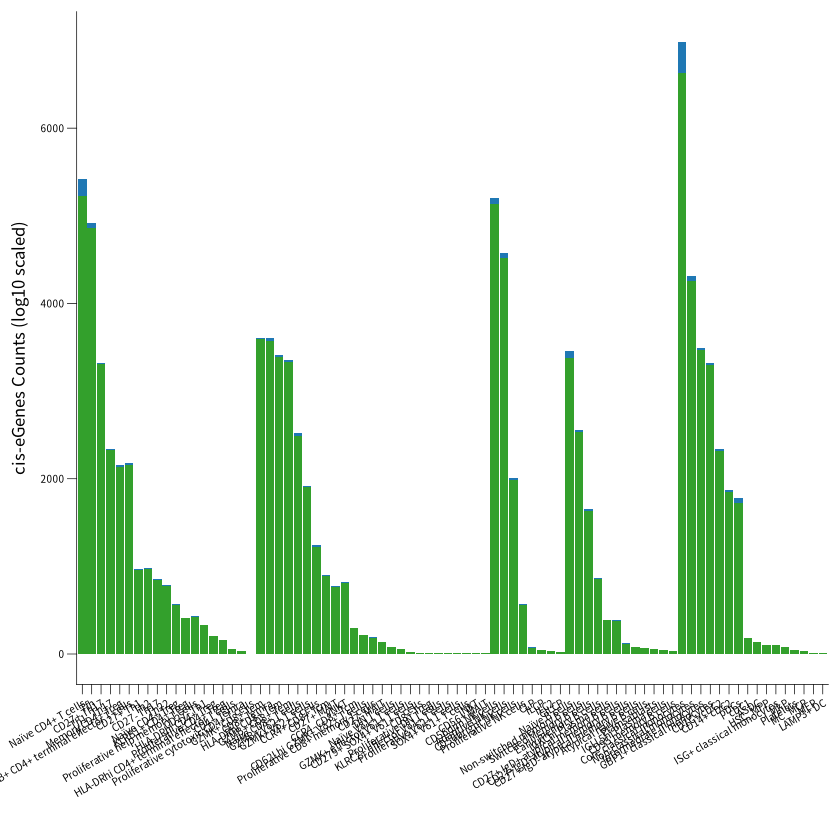

In [19]:
p1 <- ggplot(tmp_long_plot1, aes(x = celltype, y = count, fill = type)) +
     geom_bar(stat = "identity") +
     labs(x = "", y = "cis-eGenes Counts (log10 scaled)", fill = "Phenotype Type") +
     scale_fill_manual(values = c("Unique eGenes" = "#1f78b4", "Shared eGenes" = "#33a02c")) +
     mytheme
p1
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/pbmc_egene_count.pdf",p1,width=15,height=3)

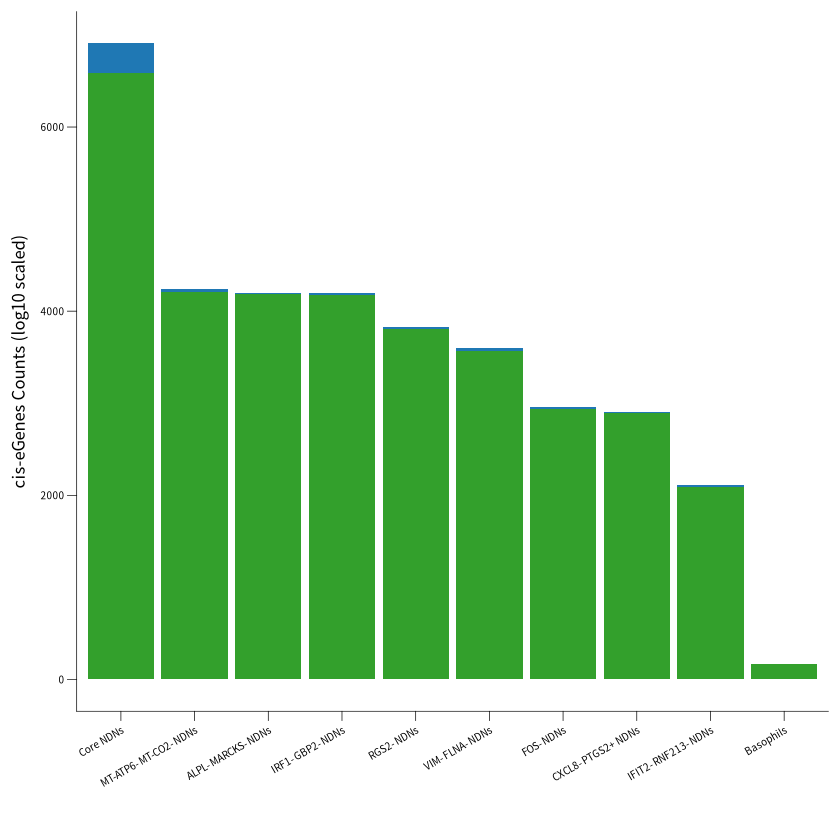

In [20]:
p2 <- ggplot(tmp_long_plot2, aes(x = celltype, y = count, fill = type)) +
     geom_bar(stat = "identity") +
     labs(x = "", y = "cis-eGenes Counts (log10 scaled)", fill = "Phenotype Type") +
     scale_fill_manual(values = c("Unique eGenes" = "#1f78b4", "Shared eGenes" = "#33a02c")) +
     mytheme
p2
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/neu_egene_count1.pdf",p2,width=15,height=3)

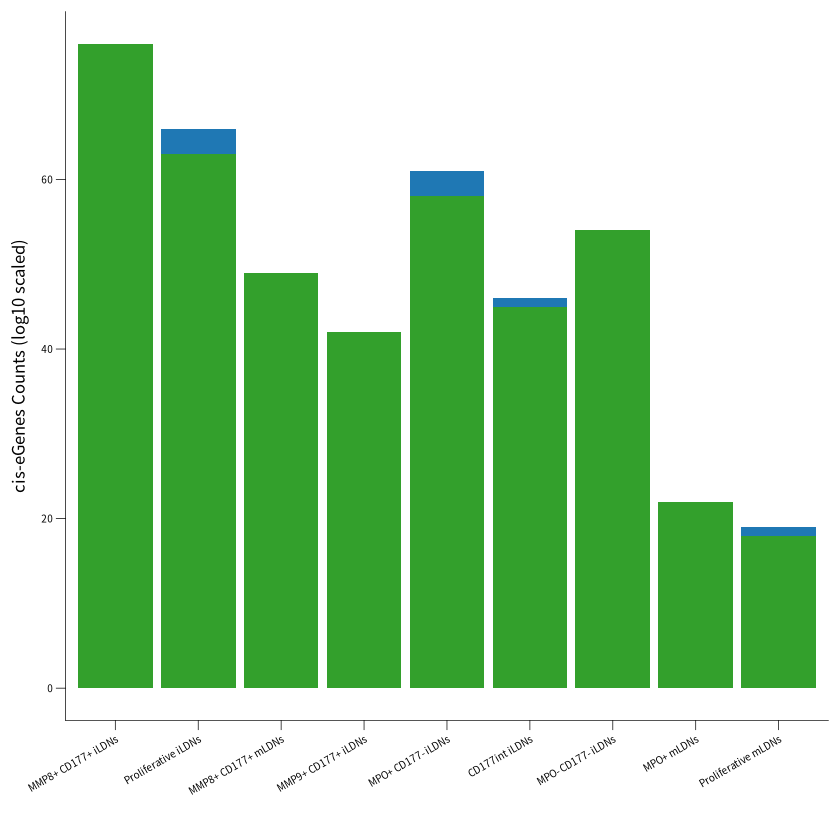

In [21]:
p2 <- ggplot(tmp_long_plot3, aes(x = celltype, y = count, fill = type)) +
     geom_bar(stat = "identity") +
     labs(x = "", y = "cis-eGenes Counts (log10 scaled)", fill = "Phenotype Type") +
     scale_fill_manual(values = c("Unique eGenes" = "#1f78b4", "Shared eGenes" = "#33a02c")) +
     mytheme
p2
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/neu_egene_count2.pdf",p2,width=15,height=3)

#### plot2

In [43]:
cellratio <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/L4_cellproportion3.csv",check.names = F,header = T))
cellratio

ClinicalID,ASDC,Adaptive NK cells,Atypical naïve B cells,CCR4+ CD8+ Tcm,CCR4- CD8+ Tcm,CD14+ cDC2,CD177int iLDNs,CD1C+ cDC2,CD27+ IgD+ atypical memory B cells,⋯,ALPL- MARCKS- NDNs,Basophils,CXCL8- PTGS2+ NDNs,Core NDNs,FOS- NDNs,IFIT2- RNF213- NDNs,IRF1- GBP2- NDNs,MT-ATP6- MT-CO2- NDNs,RGS2- NDNs,VIM- FLNA- NDNs
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
D0009,0.02,2.61,0.01,0.32,0.12,0.44,0.11,0.74,0.04,⋯,6.26,0.45,9.73,30.50,1.56,6.41,18.06,10.00,4.90,12.13
D0010,0.01,26.30,0.08,0.23,0.03,0.34,0.17,0.45,0.08,⋯,6.77,0.24,1.74,42.45,4.95,9.26,12.26,7.39,11.36,3.58
D0011,0.02,5.40,0.03,0.50,0.35,0.64,0.03,0.64,0.13,⋯,6.38,0.08,10.42,33.91,3.73,4.73,13.16,12.77,8.47,6.36
D0012,0.02,7.73,0.01,1.24,0.05,0.46,0.00,0.28,0.05,⋯,12.63,0.00,1.07,34.95,2.44,6.43,16.22,13.25,6.23,6.79
D0013,0.01,11.15,0.05,0.27,0.19,0.25,0.01,0.24,0.05,⋯,13.00,0.03,1.49,39.71,10.69,6.26,8.13,5.05,13.12,2.52
D0014,0.02,3.11,0.22,0.09,0.13,0.19,0.00,0.24,0.38,⋯,5.17,0.03,6.82,45.81,3.28,3.57,7.76,11.16,8.37,8.04
D0015,0.01,28.49,0.00,0.07,0.03,0.73,0.01,0.37,0.02,⋯,7.04,0.68,2.06,43.71,4.22,5.38,13.87,11.41,5.89,5.75
D0016,0.03,18.92,0.05,0.15,0.26,0.73,0.01,0.73,0.09,⋯,12.49,0.18,3.71,35.21,3.42,5.37,13.73,16.53,5.37,3.97
D0017,0.03,4.22,0.02,0.36,0.22,0.29,0.01,0.58,0.06,⋯,6.85,0.16,12.51,39.88,5.98,2.23,9.06,11.13,6.23,5.97


In [44]:
sample <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/sample.csv",check.names = F,header = T))
sample

WGSID,Gender,Age,ClinicalID,Batch,Pregnancy,Plate ID
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
HP-1,Female,85,D0649,B8,NO,INF-20241127-10
HP-10,Female,89,D0216,B37,NO,INF-20241127-11
HP-101,Male,29,D0721,B20,NO,INF-20241127-1
HP-103,Male,40,D0624,B20,NO,INF-20241127-1
HP-104,Female,33,D0167,B20,NO,INF-20241127-1
HP-105,Female,52,D0448,B20,NO,INF-20241127-1
HP-106,Female,40,D0902,B9,NO,INF-20241127-1
HP-107,Female,37,D0497,B9,NO,INF-20241127-1
HP-108,Female,54,D0564,B9,NO,INF-20241127-1


In [45]:
subcellratio <- subset(cellratio, ClinicalID %in% sample$ClinicalID)
subcellratio

,ClinicalID,ASDC,Adaptive NK cells,Atypical naïve B cells,CCR4+ CD8+ Tcm,CCR4- CD8+ Tcm,CD14+ cDC2,CD177int iLDNs,CD1C+ cDC2,CD27+ IgD+ atypical memory B cells,⋯,ALPL- MARCKS- NDNs,Basophils,CXCL8- PTGS2+ NDNs,Core NDNs,FOS- NDNs,IFIT2- RNF213- NDNs,IRF1- GBP2- NDNs,MT-ATP6- MT-CO2- NDNs,RGS2- NDNs,VIM- FLNA- NDNs
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,D0009,0.02,2.61,0.01,0.32,0.12,0.44,0.11,0.74,0.04,⋯,6.26,0.45,9.73,30.50,1.56,6.41,18.06,10.00,4.90,12.13
2,D0010,0.01,26.30,0.08,0.23,0.03,0.34,0.17,0.45,0.08,⋯,6.77,0.24,1.74,42.45,4.95,9.26,12.26,7.39,11.36,3.58
3,D0011,0.02,5.40,0.03,0.50,0.35,0.64,0.03,0.64,0.13,⋯,6.38,0.08,10.42,33.91,3.73,4.73,13.16,12.77,8.47,6.36
4,D0012,0.02,7.73,0.01,1.24,0.05,0.46,0.00,0.28,0.05,⋯,12.63,0.00,1.07,34.95,2.44,6.43,16.22,13.25,6.23,6.79
5,D0013,0.01,11.15,0.05,0.27,0.19,0.25,0.01,0.24,0.05,⋯,13.00,0.03,1.49,39.71,10.69,6.26,8.13,5.05,13.12,2.52
6,D0014,0.02,3.11,0.22,0.09,0.13,0.19,0.00,0.24,0.38,⋯,5.17,0.03,6.82,45.81,3.28,3.57,7.76,11.16,8.37,8.04
7,D0015,0.01,28.49,0.00,0.07,0.03,0.73,0.01,0.37,0.02,⋯,7.04,0.68,2.06,43.71,4.22,5.38,13.87,11.41,5.89,5.75
8,D0016,0.03,18.92,0.05,0.15,0.26,0.73,0.01,0.73,0.09,⋯,12.49,0.18,3.71,35.21,3.42,5.37,13.73,16.53,5.37,3.97
9,D0017,0.03,4.22,0.02,0.36,0.22,0.29,0.01,0.58,0.06,⋯,6.85,0.16,12.51,39.88,5.98,2.23,9.06,11.13,6.23,5.97


In [47]:
avg_df <- data.frame(
  CellType = colnames(subcellratio)[-1],
  Mean = colMeans(subcellratio[ , -1], na.rm = TRUE)
)
avg_df

,CellType,Mean
,<chr>,<dbl>
ASDC,ASDC,0.021910377
Adaptive NK cells,Adaptive NK cells,10.108514151
Atypical naïve B cells,Atypical naïve B cells,0.048290094
CCR4+ CD8+ Tcm,CCR4+ CD8+ Tcm,0.479221698
CCR4- CD8+ Tcm,CCR4- CD8+ Tcm,0.133408019
CD14+ cDC2,CD14+ cDC2,0.356922170
CD177int iLDNs,CD177int iLDNs,0.037617925
CD1C+ cDC2,CD1C+ cDC2,0.492794811
CD27+ IgD+ atypical memory B cells,CD27+ IgD+ atypical memory B cells,0.119834906


In [48]:
tmp <- as.data.frame(tmp)
tmp

celltype,unique_egenes,shared_egenes,total_egenes
<fct>,<int>,<int>,<int>
ALPL- MARCKS- NDNs,15,4182,4197
ASDC,0,140,140
Adaptive NK cells,52,4518,4570
Atypical naïve B cells,2,72,74
Basophils,8,163,171
CCR4+ CD8+ Tcm,11,893,904
CCR4- CD8+ Tcm,6,294,300
CD14+ cDC2,16,1851,1867
CD177int iLDNs,1,45,46


In [49]:
merged_data <- left_join(tmp, avg_df, by = c("celltype" = "CellType"))
merged_data

celltype,unique_egenes,shared_egenes,total_egenes,Mean
<chr>,<int>,<int>,<int>,<dbl>
ALPL- MARCKS- NDNs,15,4182,4197,8.551827830
ASDC,0,140,140,0.021910377
Adaptive NK cells,52,4518,4570,10.108514151
Atypical naïve B cells,2,72,74,0.048290094
Basophils,8,163,171,0.193632075
CCR4+ CD8+ Tcm,11,893,904,0.479221698
CCR4- CD8+ Tcm,6,294,300,0.133408019
CD14+ cDC2,16,1851,1867,0.356922170
CD177int iLDNs,1,45,46,0.037617925


In [50]:
merged_data <- merged_data[complete.cases(merged_data), ]
merged_data

,celltype,unique_egenes,shared_egenes,total_egenes,Mean
,<chr>,<int>,<int>,<int>,<dbl>
1,ALPL- MARCKS- NDNs,15,4182,4197,8.551827830
2,ASDC,0,140,140,0.021910377
3,Adaptive NK cells,52,4518,4570,10.108514151
4,Atypical naïve B cells,2,72,74,0.048290094
5,Basophils,8,163,171,0.193632075
6,CCR4+ CD8+ Tcm,11,893,904,0.479221698
7,CCR4- CD8+ Tcm,6,294,300,0.133408019
8,CD14+ cDC2,16,1851,1867,0.356922170
9,CD177int iLDNs,1,45,46,0.037617925


In [51]:
merged_data1 <- subset(merged_data, celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils'))
merged_data1

,celltype,unique_egenes,shared_egenes,total_egenes,Mean
,<chr>,<int>,<int>,<int>,<dbl>
1,ALPL- MARCKS- NDNs,15,4182,4197,8.5518278
5,Basophils,8,163,171,0.1936321
31,CXCL8- PTGS2+ NDNs,12,2896,2908,4.6245637
32,Core NDNs,326,6582,6908,40.1943160
36,FOS- NDNs,16,2941,2957,4.2613325
48,IFIT2- RNF213- NDNs,14,2094,2108,5.0502948
53,IRF1- GBP2- NDNs,21,4175,4196,10.8193278
67,MT-ATP6- MT-CO2- NDNs,32,4209,4241,10.8787972
88,RGS2- NDNs,23,3805,3828,7.4723585


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


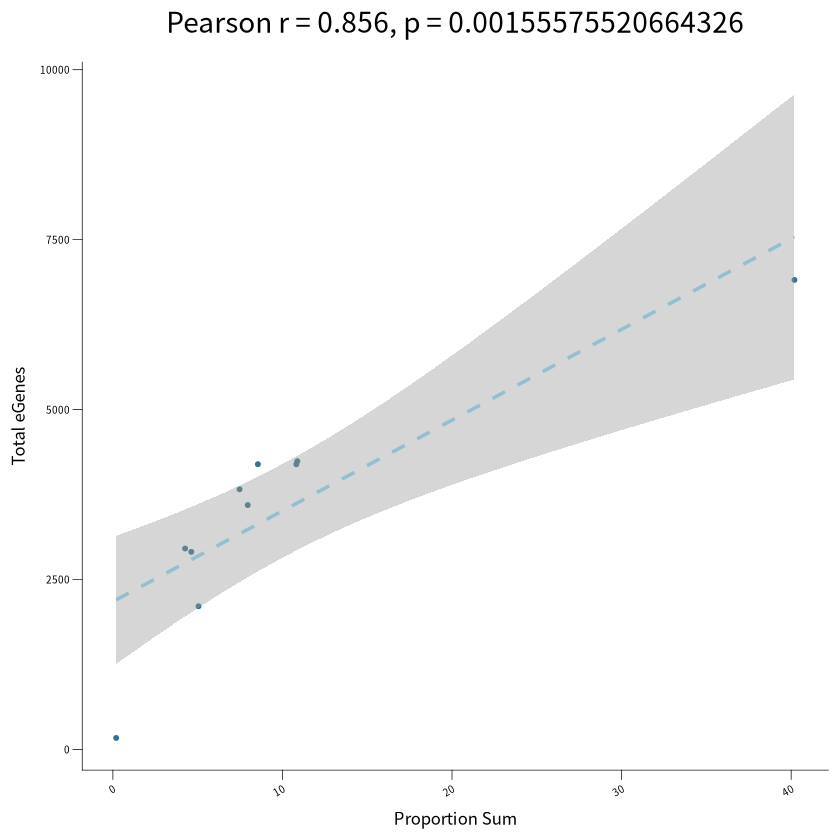

In [52]:
cor_test <- cor.test(merged_data1$total_egenes,
                     merged_data1$Mean,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(merged_data1, aes(x = Mean, y = total_egenes)) +
     geom_point(size=1,color = "#37718F") +
     geom_smooth(method = "lm", se = T, color = "#94BFD2", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/neu_egene_cor_cellratio1.pdf",p,width=3,height=3.5)

In [53]:
merged_data2 <- subset(merged_data, celltype %in% c('MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs','Proliferative mLDNs'))
merged_data2

,celltype,unique_egenes,shared_egenes,total_egenes,Mean
,<chr>,<int>,<int>,<int>,<dbl>
9,CD177int iLDNs,1,45,46,0.037617925
61,MMP8+ CD177+ iLDNs,0,76,76,0.054823113
62,MMP8+ CD177+ mLDNs,0,49,49,0.040353774
63,MMP9+ CD177+ iLDNs,0,42,42,0.033691038
64,MPO+ CD177- iLDNs,3,58,61,0.057712264
65,MPO+ mLDNs,0,22,22,0.024882075
66,MPO- CD177- iLDNs,0,54,54,0.042936321
86,Proliferative iLDNs,3,63,66,0.044705189
87,Proliferative mLDNs,1,18,19,0.009504717


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


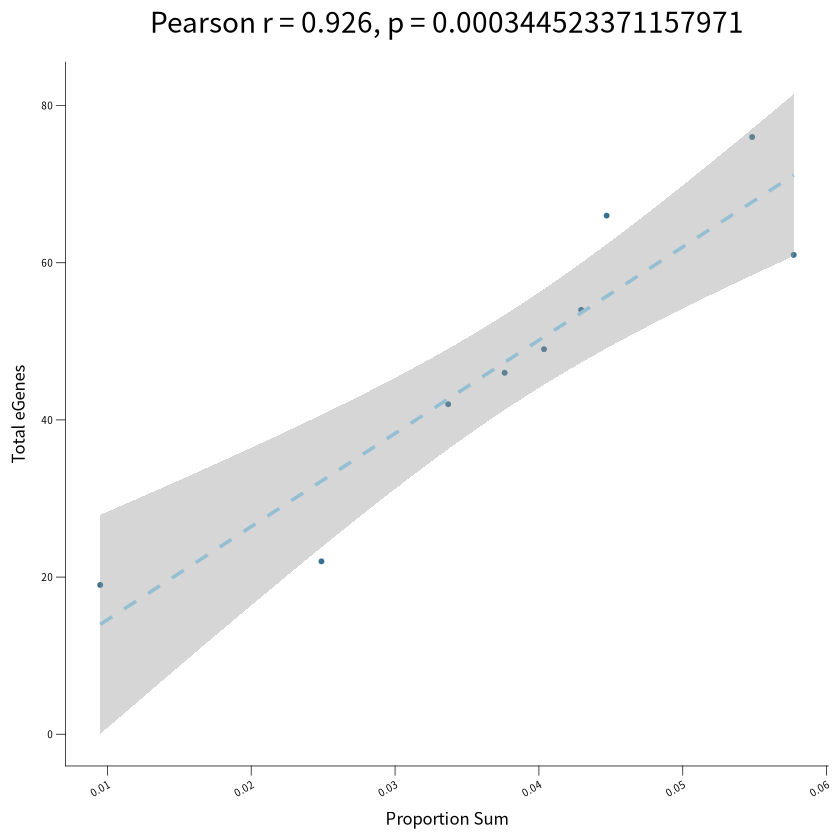

In [58]:
cor_test <- cor.test(merged_data2$total_egenes,
                     merged_data2$Mean,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(merged_data2, aes(x = Mean, y = total_egenes)) +
     geom_point(size=1,color = "#37718F") +
     geom_smooth(method = "lm", se = T, color = "#94BFD2", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/neu_egene_cor_cellratio2.pdf",p,width=3,height=3.5)

In [55]:
merged_data3 <- subset(merged_data, !(celltype %in% c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs','Proliferative mLDNs')))
merged_data3

,celltype,unique_egenes,shared_egenes,total_egenes,Mean
,<chr>,<int>,<int>,<int>,<dbl>
2,ASDC,0,140,140,0.021910377
3,Adaptive NK cells,52,4518,4570,10.108514151
4,Atypical naïve B cells,2,72,74,0.048290094
6,CCR4+ CD8+ Tcm,11,893,904,0.479221698
7,CCR4- CD8+ Tcm,6,294,300,0.133408019
8,CD14+ cDC2,16,1851,1867,0.356922170
10,CD1C+ cDC2,24,2311,2335,0.492794811
11,CD27+ IgD+ atypical memory B cells,8,375,383,0.119834906
12,CD27+ IgD- atypical memory B cells,1,82,83,0.038962264


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


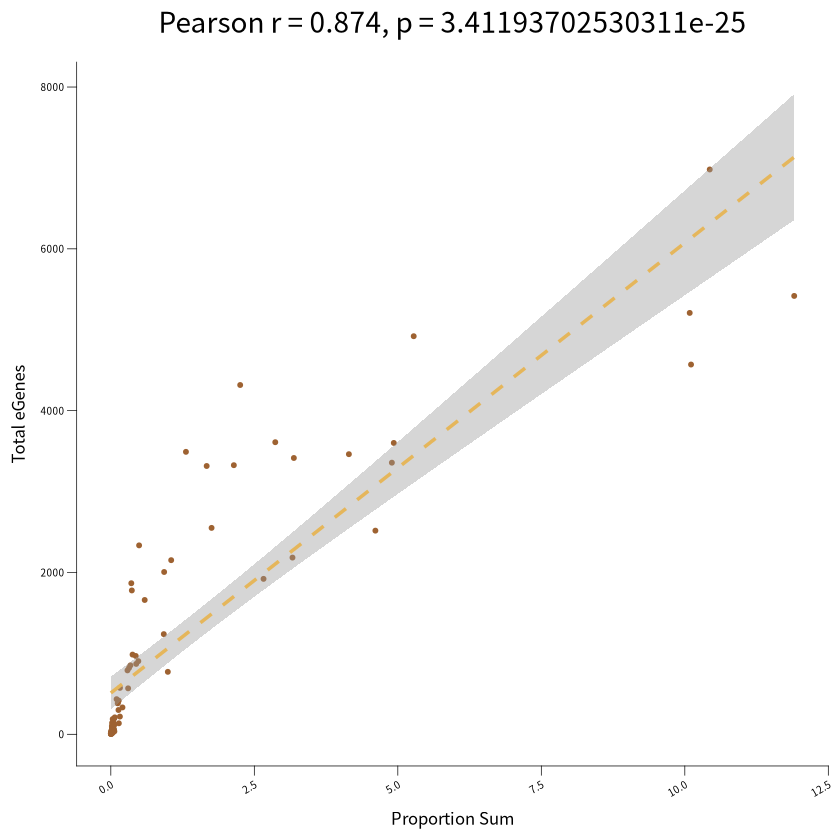

In [57]:
cor_test <- cor.test(merged_data3$total_egenes,
                     merged_data3$Mean,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(merged_data3, aes(x = Mean, y = total_egenes)) +
     geom_point(size=1,color = "#9E6231") +
     geom_smooth(method = "lm", se = T, color = "#E5B65B", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/egene/pbmc_egene_cor_cellratio.pdf",p,width=3,height=3.5)

#### plot3

In [53]:
# 设置目录
input_dir <- '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scRNA-seq/02.normal_dis//'

# 获取所有csv文件路径
csv_files <- list.files(input_dir, pattern = "\\.csv$", full.names = TRUE)

# 初始化结果列表
result_list <- lapply(csv_files, function(file) {
  df <- read.csv(file, header = TRUE)
  gene_count <- ncol(df)
  data.frame(
    file_name = tools::file_path_sans_ext(basename(file)),
    sample_count = gene_count
  )
})

# 合并为一个dataframe
result_df <- do.call(rbind, result_list)
result_df

file_name,sample_count
<chr>,<int>
Adaptive NK cells,13138
ALPL- MARCKS- NDNs,12104
ASDC,2320
Atypical naïve B cells,1156
Basophils,2739
CCR4- CD8+ Tcm,4879
CCR4+ CD8+ Tcm,8482
CD14+ cDC2,9792
CD177int iLDNs,737


In [54]:
result_df$file_name <- factor(result_df$file_name,levels = c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP','LAMP3+ DC','Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                                             'Proliferative mLDNs'))

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Naïve Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ effector Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD279+ SOX4+ Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warn

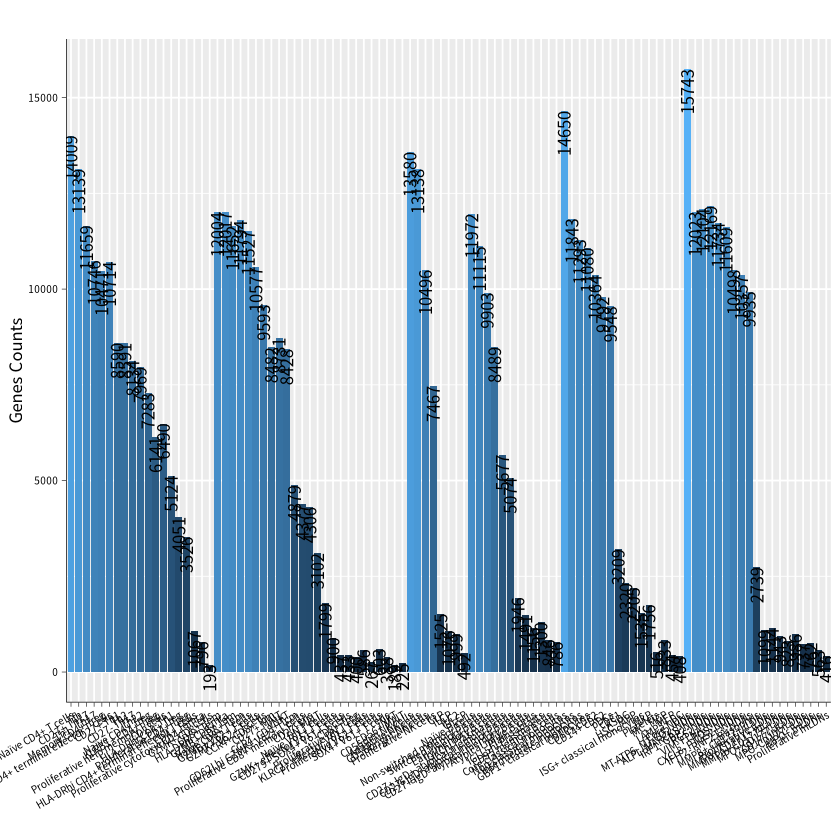

In [57]:
p <- ggplot(result_df, aes(x = file_name, y = sample_count, fill = sample_count)) +
     geom_bar(stat = "identity") +
     labs(title = "",x = "", y = "Genes Counts", fill = "Phenotype Type") +
     geom_text(aes(label = sample_count), size = 3.5,angle = 90, hjust = 1) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/egene/Gene_count.pdf",p,width=15,height=3)

#### plot4

In [58]:
# 设置目录
input_dir <- '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scRNA-seq/02.normal_dis//'

# 获取所有csv文件路径
csv_files <- list.files(input_dir, pattern = "\\.csv$", full.names = TRUE)

# 初始化结果列表
result_list <- lapply(csv_files, function(file) {
  df <- read.csv(file, header = TRUE)
  sample_count <- nrow(df)
  data.frame(
    file_name = tools::file_path_sans_ext(basename(file)),
    sample_count = sample_count
  )
})

# 合并为一个dataframe
result_df <- do.call(rbind, result_list)
result_df

file_name,sample_count
<chr>,<int>
Adaptive NK cells,863
ALPL- MARCKS- NDNs,860
ASDC,829
Atypical naïve B cells,841
Basophils,845
CCR4- CD8+ Tcm,861
CCR4+ CD8+ Tcm,863
CD14+ cDC2,863
CD177int iLDNs,725


In [59]:
result_df$file_name <- factor(result_df$file_name,levels = c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells',
                                                             'CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP','LAMP3+ DC','Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs',
                                                             'Proliferative mLDNs'))

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Naïve Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ effector Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD279+ SOX4+ Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warn

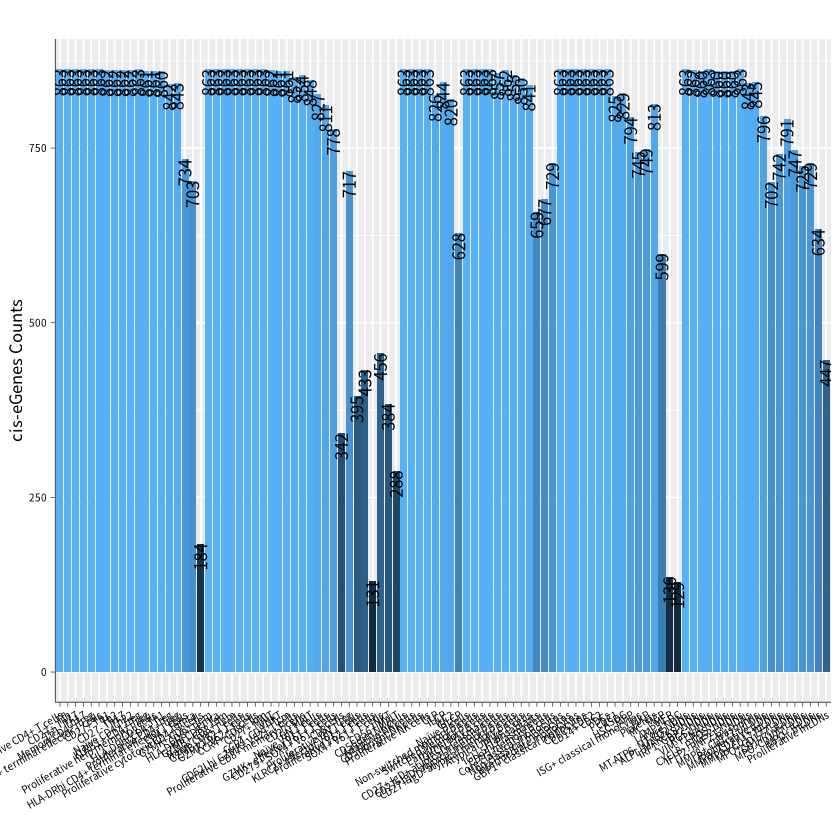

In [60]:
p <- ggplot(result_df, aes(x = file_name, y = sample_count, fill = sample_count)) +
     geom_bar(stat = "identity") +
     labs(title = "",x = "", y = "cis-eGenes Counts", fill = "Phenotype Type") +
     geom_text(aes(label = sample_count), size = 3.5,angle = 90, hjust = 1) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/egene/sample_count.pdf",p,width=15,height=3)

### ADT-QTL

#### permutations caPeak统计

In [69]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/pQTL_all_lead_perm_qvalues.csv",check.names = F,header = T))
data

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,study_wise_qval,study_wise_nominal_threshold
<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
0,TNFRSF18,2817,1.049145,175.67972,696.8889,2.201904e-10,1:1217733:G:A,14224,11141,⋯,0.2688297,3.209596e-12,-0.13807149,0.019522840,0.00009999,1.636577e-08,Adaptive NK cells,0.000659934,2.568024e-07,7.420554e-05
1,TNFRSF4,2829,1.047612,197.72368,712.7945,4.462068e-05,1:1649976:G:A,438649,435823,⋯,0.2520278,9.349625e-06,-0.05573715,0.012499745,0.00589941,6.867978e-03,Adaptive NK cells,0.021631170,3.741960e-02,6.546994e-05
2,TNFRSF9,1680,1.039766,109.49462,696.5448,2.875247e-09,1:7890976:C:G,-24896,-52189,⋯,0.4739281,6.942839e-11,0.08660356,0.013107186,0.00009999,1.706374e-07,Adaptive NK cells,0.000659934,2.292037e-06,1.139827e-04
3,FCGR3A,2978,1.054345,177.98178,707.9965,2.863136e-04,1:161528952:T:C,-12808,-22016,⋯,0.3968714,7.772486e-05,-0.06521195,0.016422330,0.03969603,4.124709e-02,Adaptive NK cells,0.109164084,1.428755e-01,7.501034e-05
4,FCGR3B,2967,1.045924,183.65564,713.4631,2.711962e-04,1:161528952:T:C,-94245,-103011,⋯,0.3968714,7.772486e-05,-0.06521195,0.016422330,0.03959604,4.147995e-02,Adaptive NK cells,0.109164084,1.431868e-01,6.993687e-05
5,SELL,2172,1.014876,64.04605,699.6812,8.159907e-04,1:169729780:C:T,39114,18078,⋯,0.1326767,2.445974e-04,-0.09969975,0.027065188,0.04699530,4.843834e-02,Adaptive NK cells,0.115959833,1.603517e-01,1.729994e-04
6,CD8A,1832,1.017847,47.30919,672.7690,1.667638e-04,2:85937145:A:T,-847466,-871251,⋯,0.1477404,2.588490e-05,-0.14355183,0.033932835,0.00569943,7.154638e-03,Adaptive NK cells,0.021631170,3.818590e-02,2.375969e-04
7,CD8B,1769,1.004540,42.89640,676.6261,1.597111e-04,2:85937145:A:T,-878195,-924779,⋯,0.1477404,2.588490e-05,-0.14355183,0.033932835,0.00529947,6.662874e-03,Adaptive NK cells,0.021631170,3.681340e-02,2.454481e-04
8,CD28,1073,1.040410,40.24059,691.4059,5.957628e-02,2:203642991:T:C,-63485,-95921,⋯,0.3006952,3.783423e-02,-0.02259308,0.010862400,0.90950905,9.094615e-01,Adaptive NK cells,0.914108589,6.801117e-01,3.109524e-04


In [70]:
sub_data <- subset(data, study_wise_qval < 0.05)
sub_data

,,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,⋯,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,study_wise_qval,study_wise_nominal_threshold
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,0,TNFRSF18,2817,1.049145,175.67972,696.8889,2.201904e-10,1:1217733:G:A,14224,11141,⋯,0.2688297,3.209596e-12,-0.13807149,0.01952284,0.00009999,1.636577e-08,Adaptive NK cells,0.000659934,2.568024e-07,7.420554e-05
2,1,TNFRSF4,2829,1.047612,197.72368,712.7945,4.462068e-05,1:1649976:G:A,438649,435823,⋯,0.2520278,9.349625e-06,-0.05573715,0.01249974,0.00589941,6.867978e-03,Adaptive NK cells,0.021631170,3.741960e-02,6.546994e-05
3,2,TNFRSF9,1680,1.039766,109.49462,696.5448,2.875247e-09,1:7890976:C:G,-24896,-52189,⋯,0.4739281,6.942839e-11,0.08660356,0.01310719,0.00009999,1.706374e-07,Adaptive NK cells,0.000659934,2.292037e-06,1.139827e-04
7,6,CD8A,1832,1.017847,47.30919,672.7690,1.667638e-04,2:85937145:A:T,-847466,-871251,⋯,0.1477404,2.588490e-05,-0.14355183,0.03393284,0.00569943,7.154638e-03,Adaptive NK cells,0.021631170,3.818590e-02,2.375969e-04
8,7,CD8B,1769,1.004540,42.89640,676.6261,1.597111e-04,2:85937145:A:T,-878195,-924779,⋯,0.1477404,2.588490e-05,-0.14355183,0.03393284,0.00529947,6.662874e-03,Adaptive NK cells,0.021631170,3.681340e-02,2.454481e-04
17,16,HLA-DRA,13631,1.057797,198.72008,625.1773,6.820233e-09,6:32693361:A:C,253481,248314,⋯,0.1778679,1.838922e-11,0.17340337,0.02545703,0.00009999,6.051806e-07,Adaptive NK cells,0.000659934,7.361358e-06,6.824544e-05
18,17,HLA-DRB1,13115,1.058529,189.79187,623.9265,7.060164e-09,6:32693361:A:C,115457,103512,⋯,0.1778679,1.838922e-11,0.17340337,0.02545703,0.00009999,5.918415e-07,Adaptive NK cells,0.000659934,7.255346e-06,7.169265e-05
20,19,IL2RA,2831,1.042796,209.17833,717.1782,1.218728e-06,10:6015268:T:G,4578,-47102,⋯,0.3192352,1.505046e-07,-0.10776024,0.02034383,0.00009999,1.755941e-04,Adaptive NK cells,0.000659934,1.412986e-03,6.052033e-05
29,28,IGHD,3519,1.025616,131.82237,694.9921,8.356124e-05,14:105703800:T:G,-132966,-141877,⋯,0.4414832,1.523988e-05,-0.06025953,0.01385056,0.00939906,9.653516e-03,Adaptive NK cells,0.031016898,4.793592e-02,8.854634e-05


In [71]:
length(unique(sub_data$phenotype_id))

[1] 29

In [72]:
write.csv(sub_data,'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/pQTL_all_lead_perm_qvalues_0.05.csv')

#### plot1

In [73]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/pQTL_all_lead_perm_qvalues.csv",check.names = F,header = T))

In [74]:
subdata <- subset(data,study_wise_qval < 0.05)
subdata <- subdata[,-c(1)]
subdata

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,⋯,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,study_wise_qval,study_wise_nominal_threshold
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,TNFRSF18,2817,1.049145,175.67972,696.8889,2.201904e-10,1:1217733:G:A,14224,11141,395,⋯,0.2688297,3.209596e-12,-0.13807149,0.01952284,0.00009999,1.636577e-08,Adaptive NK cells,0.000659934,2.568024e-07,7.420554e-05
2,TNFRSF4,2829,1.047612,197.72368,712.7945,4.462068e-05,1:1649976:G:A,438649,435823,387,⋯,0.2520278,9.349625e-06,-0.05573715,0.01249974,0.00589941,6.867978e-03,Adaptive NK cells,0.021631170,3.741960e-02,6.546994e-05
3,TNFRSF9,1680,1.039766,109.49462,696.5448,2.875247e-09,1:7890976:C:G,-24896,-52189,624,⋯,0.4739281,6.942839e-11,0.08660356,0.01310719,0.00009999,1.706374e-07,Adaptive NK cells,0.000659934,2.292037e-06,1.139827e-04
7,CD8A,1832,1.017847,47.30919,672.7690,1.667638e-04,2:85937145:A:T,-847466,-871251,236,⋯,0.1477404,2.588490e-05,-0.14355183,0.03393284,0.00569943,7.154638e-03,Adaptive NK cells,0.021631170,3.818590e-02,2.375969e-04
8,CD8B,1769,1.004540,42.89640,676.6261,1.597111e-04,2:85937145:A:T,-878195,-924779,236,⋯,0.1477404,2.588490e-05,-0.14355183,0.03393284,0.00529947,6.662874e-03,Adaptive NK cells,0.021631170,3.681340e-02,2.454481e-04
17,HLA-DRA,13631,1.057797,198.72008,625.1773,6.820233e-09,6:32693361:A:C,253481,248314,282,⋯,0.1778679,1.838922e-11,0.17340337,0.02545703,0.00009999,6.051806e-07,Adaptive NK cells,0.000659934,7.361358e-06,6.824544e-05
18,HLA-DRB1,13115,1.058529,189.79187,623.9265,7.060164e-09,6:32693361:A:C,115457,103512,282,⋯,0.1778679,1.838922e-11,0.17340337,0.02545703,0.00009999,5.918415e-07,Adaptive NK cells,0.000659934,7.255346e-06,7.169265e-05
20,IL2RA,2831,1.042796,209.17833,717.1782,1.218728e-06,10:6015268:T:G,4578,-47102,461,⋯,0.3192352,1.505046e-07,-0.10776024,0.02034383,0.00009999,1.755941e-04,Adaptive NK cells,0.000659934,1.412986e-03,6.052033e-05
29,IGHD,3519,1.025616,131.82237,694.9921,8.356124e-05,14:105703800:T:G,-132966,-141877,591,⋯,0.4414832,1.523988e-05,-0.06025953,0.01385056,0.00939906,9.653516e-03,Adaptive NK cells,0.031016898,4.793592e-02,8.854634e-05


In [75]:
colnames(subdata)

[1] "phenotype_id"                 "num_var"                     
 [3] "beta_shape1"                  "beta_shape2"                 
 [5] "true_df"                      "pval_true_df"                
 [7] "variant_id"                   "start_distance"              
 [9] "end_distance"                 "ma_samples"                  
[11] "ma_count"                     "af"                          
[13] "pval_nominal"                 "slope"                       
[15] "slope_se"                     "pval_perm"                   
[17] "pval_beta"                    "celltype"                    
[19] "celltype_level_qval"          "study_wise_qval"             
[21] "study_wise_nominal_threshold"

In [76]:
length(unique(subdata$phenotype_id))

[1] 29

In [77]:
# 每个 phenotype_id 出现在哪些 celltype
pheno_cell_map <- subdata %>%
  distinct(celltype, phenotype_id) %>%
  group_by(phenotype_id) %>%
  summarise(celltype_count = n(),
            celltypes = paste(sort(unique(celltype)), collapse = ",")) %>%
  ungroup()

In [78]:
# 特有的 phenotype_id
unique_phenos <- pheno_cell_map %>%
  filter(celltype_count == 1)

# 共享的 phenotype_id
shared_phenos <- pheno_cell_map %>%
  filter(celltype_count > 1)

In [86]:
# 合并 celltype 到 pheno 表
df_pheno_info <- subdata %>%
  distinct(celltype, phenotype_id) %>%
  left_join(pheno_cell_map, by = "phenotype_id")

# 每个 celltype 的统计
tmp <- df_pheno_info %>% group_by(celltype) %>%
       summarise(unique_phenotype_n = sum(celltype_count == 1),
                 shared_phenotype_n = sum(celltype_count > 1))
tmp$total_egenes <- tmp$unique_phenotype_n + tmp$shared_phenotype_n
colnames(tmp) <- c('celltype','unique_egenes','shared_egenes','total_egenes')
tmp$celltype <- factor(tmp$celltype,levels = c('Th1_Th17','Adaptive NK cells','CD27- Th17','CD27+ Th17','CD56bright NK cells','GZMK+ CD8+ Tem','Memory CD4+ Treg','Non-switched memory B cells','vNKT','CD1C+ cDC2','CD27+ Th1','CD56dim NK cells','CD8+ Temra','GBP1+ classical monocytes','Naïve CD4+ T cells','Tfh','Th2','Th22','GZMB+ CD8+ Tem','GZMK+ Vδ2+ T cells','HLA-DRhi CD8+ Tem','Intermediate monocytes','Naïve CD8+ T cells','Switched Memory B cells','CD14+ cDC2','CD27+ MAIT','CD27- Th1','Core classical monocytes','GZMB+ CD4+ terminal effector T cells','GZMB+ Vδ2+ T cells','Naïve B cells','ASDC','CD27+ IgD+ atypical memory B cells','Early memory B cells','MMElo pre-mature neutrophils','Naïve CD4+ Treg','Non-classical monocytes','Proliferative NK cells','Proliferative help memory T cells','pDCs','CCR4- CD8+ Tcm','CD27- IgD- atypical memory B cells','CXCR4- CXCL8- mature neutrophils','Core mature neutrophils','FOS- mature neutrophils','ILCP','IRF1- GBP2- mature neutrophils','Atypical naïve B cells','Basophils','CCR4+ CD8+ Tcm','CD27+ IgD- atypical memory B cells','CD62Lhi GZMK+ Vδ2+ T cells','CD95 memory B cells','CILCP','CLP','HLA-DRhi CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','HSC_MPP','IGKChi Plasma cells','IGLL5hi Plasma cells','ISG+ classical monocytes','MC_MCP','MEP','MkP','PADI4+ CD177+ MMP9+ immature neutrophils','Plamsablasts','Platelets','Proliferative CD4+ Treg','Proliferative CD8+ memory T cells','Proliferative DN T cells','RGS2- mature neutrophils',
                                               'MPO+ mature neutrophils'))
tmp

celltype,unique_egenes,shared_egenes,total_egenes
<fct>,<int>,<int>,<int>
ASDC,0,4,4
Adaptive NK cells,0,10,10
Atypical naïve B cells,0,2,2
Basophils,0,2,2
CCR4+ CD8+ Tcm,0,2,2
CCR4- CD8+ Tcm,0,3,3
CD14+ cDC2,0,5,5
CD1C+ cDC2,0,7,7
CD27+ IgD+ atypical memory B cells,0,4,4


In [87]:
tmp_long <- tmp %>%
  pivot_longer(cols = c(unique_egenes, shared_egenes),
               names_to = "type",
               values_to = "count") %>%
  mutate(type = recode(type,
                       shared_egenes = "Shared eGenes",
                       unique_egenes = "Unique eGenes"))
tmp_long$type <- factor(tmp_long$type, levels = c('Unique eGenes','Shared eGenes'))

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”


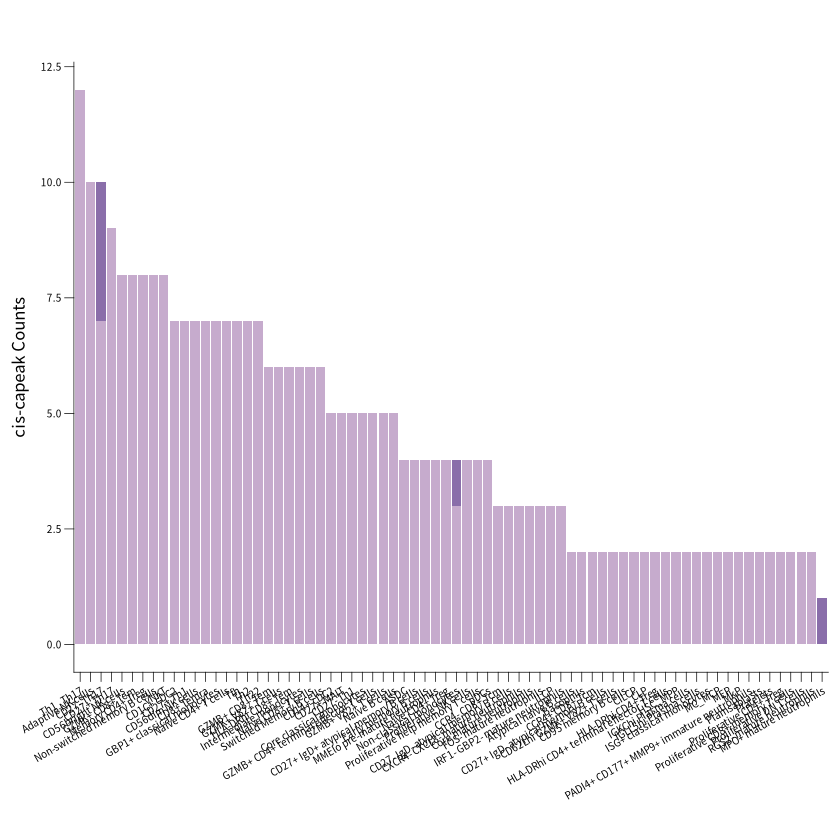

In [90]:
p <- ggplot(tmp_long, aes(x = celltype, y = count, fill = type)) +
     geom_bar(stat = "identity") +
     labs(title = "",
          x = "", y = "cis-capeak Counts", fill = "Phenotype Type") +
     scale_fill_manual(values = c("Unique eGenes" = "#8A6EAA", "Shared eGenes" = "#C6ABCD"))+
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/all_pqtl_count.pdf",p,width=15,height=3)

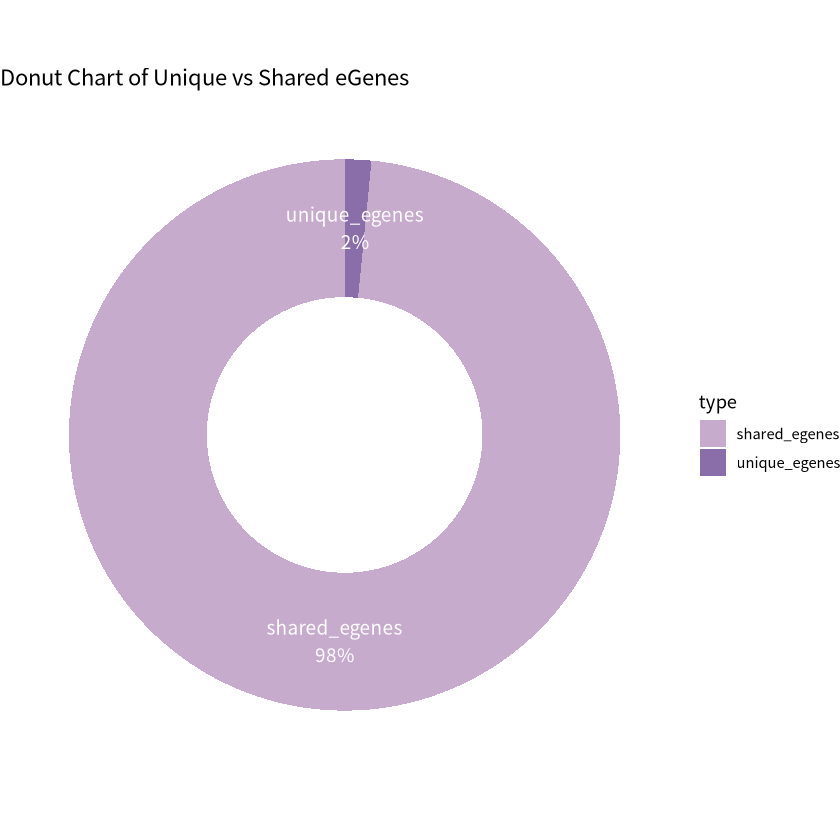

In [91]:
# 计算总和
gene_counts <- colSums(tmp[, c("unique_egenes", "shared_egenes")], na.rm = TRUE)

# 转为 dataframe
gene_df <- data.frame(
  type = names(gene_counts),
  count = as.numeric(gene_counts)
)

# 计算百分比 & 添加标签
gene_df$fraction <- gene_df$count / sum(gene_df$count)
gene_df$ymax <- cumsum(gene_df$fraction)
gene_df$ymin <- c(0, head(gene_df$ymax, n = -1))
gene_df$label <- paste0(gene_df$type, "\n", round(gene_df$fraction * 100), "%")

# 绘制圆环图
p <- ggplot(gene_df, aes(ymax = ymax, ymin = ymin, xmax = 4, xmin = 3, fill = type)) +
  geom_rect() +s
  coord_polar(theta = "y") +
  xlim(c(2, 4)) +  # 控制中间空心
  theme_void() +
  scale_fill_manual(values = c("unique_egenes" = "#8A6EAA", "shared_egenes" = "#C6ABCD")) +
  geom_text(aes(x = 3.5, y = (ymin + ymax)/2, label = label), color = "white", size = 4) +
  labs(title = "Donut Chart of Unique vs Shared eGenes") +
  theme(legend.position = "right")
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/pQTL_ratio.pdf",p,width=5,height=5)

#### plot2

In [92]:
cellratio <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/L4_cellproportion.csv",check.names = F,header = T))
cellratio

ClinicalID,ASDC,Adaptive NK cells,Atypical naïve B cells,CCR4+ CD8+ Tcm,CCR4- CD8+ Tcm,CD14+ cDC2,CD1C+ cDC2,CD27+ IgD+ atypical memory B cells,CD27+ IgD- atypical memory B cells,⋯,iNKT,pDCs,vNKT,Basophils,CXCR4- CXCL8- mature neutrophils,Core mature neutrophils,FOS- mature neutrophils,IRF1- GBP2- mature neutrophils,MMElo pre-mature neutrophils,RGS2- mature neutrophils
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
D0009,0.01,2.72,0.01,0.32,0.10,0.38,0.66,0.04,0.02,⋯,0.00,0.51,0.30,0.58,8.98,46.98,4.73,27.67,4.80,6.26
D0009,0.02,2.52,0.01,0.31,0.14,0.49,0.80,0.04,0.06,⋯,0.00,0.63,0.23,0.32,9.09,43.16,5.29,31.15,4.53,6.48
D0010,0.01,26.91,0.03,0.24,0.03,0.26,0.41,0.08,0.00,⋯,0.00,0.26,0.38,0.22,1.27,49.91,14.16,15.71,3.40,15.33
D0010,0.01,25.69,0.13,0.22,0.03,0.41,0.50,0.08,0.01,⋯,0.00,0.29,0.39,0.25,1.39,48.62,13.80,16.69,2.75,16.50
D0011,0.02,5.39,0.02,0.52,0.31,0.63,0.64,0.16,0.10,⋯,0.00,0.46,0.16,0.05,15.34,44.05,9.91,21.77,3.26,5.61
D0011,0.02,5.43,0.04,0.49,0.38,0.64,0.65,0.10,0.07,⋯,0.00,0.40,0.17,0.10,13.98,45.36,9.68,20.69,3.64,6.55
D0012,0.05,7.49,0.00,1.30,0.05,0.43,0.18,0.06,0.00,⋯,0.00,0.26,0.14,0.00,1.63,59.22,7.38,20.76,4.81,6.20
D0012,0.00,8.01,0.03,1.19,0.06,0.48,0.37,0.04,0.01,⋯,0.00,0.18,0.28,0.00,2.06,56.24,7.33,22.87,5.03,6.46
D0013,0.01,11.19,0.04,0.28,0.22,0.24,0.24,0.05,0.03,⋯,0.01,0.05,1.13,0.01,1.38,40.23,24.94,11.40,8.11,13.92


In [93]:
sample <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/sample.csv",check.names = F,header = T))
sample

DonorID,Gender,Age,ClinicalID,Batch,Pregnancy
<chr>,<chr>,<int>,<chr>,<chr>,<chr>
HP-1,Female,85,D0649,B8,NO
HP-10,Female,89,D0216,B37,NO
HP-100,Female,31,D0475,B20,NO
HP-101,Male,29,D0721,B20,NO
HP-102,Male,59,D0496,B20,NO
HP-103,Male,40,D0624,B20,NO
HP-104,Female,33,D0167,B20,NO
HP-105,Female,52,D0448,B20,NO
HP-106,Female,40,D0902,B9,NO


In [94]:
subcellratio <- subset(cellratio, ClinicalID %in% sample$ClinicalID)
subcellratio

,ClinicalID,ASDC,Adaptive NK cells,Atypical naïve B cells,CCR4+ CD8+ Tcm,CCR4- CD8+ Tcm,CD14+ cDC2,CD1C+ cDC2,CD27+ IgD+ atypical memory B cells,CD27+ IgD- atypical memory B cells,⋯,iNKT,pDCs,vNKT,Basophils,CXCR4- CXCL8- mature neutrophils,Core mature neutrophils,FOS- mature neutrophils,IRF1- GBP2- mature neutrophils,MMElo pre-mature neutrophils,RGS2- mature neutrophils
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,D0009,0.01,2.72,0.01,0.32,0.10,0.38,0.66,0.04,0.02,⋯,0.00,0.51,0.30,0.58,8.98,46.98,4.73,27.67,4.80,6.26
2,D0009,0.02,2.52,0.01,0.31,0.14,0.49,0.80,0.04,0.06,⋯,0.00,0.63,0.23,0.32,9.09,43.16,5.29,31.15,4.53,6.48
3,D0010,0.01,26.91,0.03,0.24,0.03,0.26,0.41,0.08,0.00,⋯,0.00,0.26,0.38,0.22,1.27,49.91,14.16,15.71,3.40,15.33
4,D0010,0.01,25.69,0.13,0.22,0.03,0.41,0.50,0.08,0.01,⋯,0.00,0.29,0.39,0.25,1.39,48.62,13.80,16.69,2.75,16.50
5,D0011,0.02,5.39,0.02,0.52,0.31,0.63,0.64,0.16,0.10,⋯,0.00,0.46,0.16,0.05,15.34,44.05,9.91,21.77,3.26,5.61
6,D0011,0.02,5.43,0.04,0.49,0.38,0.64,0.65,0.10,0.07,⋯,0.00,0.40,0.17,0.10,13.98,45.36,9.68,20.69,3.64,6.55
7,D0012,0.05,7.49,0.00,1.30,0.05,0.43,0.18,0.06,0.00,⋯,0.00,0.26,0.14,0.00,1.63,59.22,7.38,20.76,4.81,6.20
8,D0012,0.00,8.01,0.03,1.19,0.06,0.48,0.37,0.04,0.01,⋯,0.00,0.18,0.28,0.00,2.06,56.24,7.33,22.87,5.03,6.46
9,D0013,0.01,11.19,0.04,0.28,0.22,0.24,0.24,0.05,0.03,⋯,0.01,0.05,1.13,0.01,1.38,40.23,24.94,11.40,8.11,13.92


In [95]:
avg_df <- data.frame(
  CellType = colnames(subcellratio)[-1],
  Mean = colMeans(subcellratio[ , -1], na.rm = TRUE)
)
avg_df

,CellType,Mean
,<chr>,<dbl>
ASDC,ASDC,0.022074160
Adaptive NK cells,Adaptive NK cells,10.049385863
Atypical naïve B cells,Atypical naïve B cells,0.050150637
CCR4+ CD8+ Tcm,CCR4+ CD8+ Tcm,0.474397451
CCR4- CD8+ Tcm,CCR4- CD8+ Tcm,0.133823870
CD14+ cDC2,CD14+ cDC2,0.362415991
CD1C+ cDC2,CD1C+ cDC2,0.496587486
CD27+ IgD+ atypical memory B cells,CD27+ IgD+ atypical memory B cells,0.122190035
CD27+ IgD- atypical memory B cells,CD27+ IgD- atypical memory B cells,0.039640788


In [96]:
tmp <- as.data.frame(tmp)
tmp

celltype,unique_egenes,shared_egenes,total_egenes
<fct>,<int>,<int>,<int>
ASDC,0,4,4
Adaptive NK cells,0,10,10
Atypical naïve B cells,0,2,2
Basophils,0,2,2
CCR4+ CD8+ Tcm,0,2,2
CCR4- CD8+ Tcm,0,3,3
CD14+ cDC2,0,5,5
CD1C+ cDC2,0,7,7
CD27+ IgD+ atypical memory B cells,0,4,4


In [98]:
merged_data <- left_join(tmp, avg_df, by = c("celltype" = "CellType"))
merged_data

celltype,unique_egenes,shared_egenes,total_egenes,Mean
<chr>,<int>,<int>,<int>,<dbl>
ASDC,0,4,4,0.022074160
Adaptive NK cells,0,10,10,10.049385863
Atypical naïve B cells,0,2,2,0.050150637
Basophils,0,2,2,0.198314021
CCR4+ CD8+ Tcm,0,2,2,0.474397451
CCR4- CD8+ Tcm,0,3,3,0.133823870
CD14+ cDC2,0,5,5,0.362415991
CD1C+ cDC2,0,7,7,0.496587486
CD27+ IgD+ atypical memory B cells,0,4,4,0.122190035


In [99]:
merged_data1 <- subset(merged_data, !(celltype %in% c('Core mature neutrophils','IRF1- GBP2- mature neutrophils','FOS- mature neutrophils','RGS2- mature neutrophils','MMElo pre-mature neutrophils','CXCR4- CXCL8- mature neutrophils',
                                                    'Basophils')))
merged_data1

,celltype,unique_egenes,shared_egenes,total_egenes,Mean
,<chr>,<int>,<int>,<int>,<dbl>
1,ASDC,0,4,4,0.022074160
2,Adaptive NK cells,0,10,10,10.049385863
3,Atypical naïve B cells,0,2,2,0.050150637
5,CCR4+ CD8+ Tcm,0,2,2,0.474397451
6,CCR4- CD8+ Tcm,0,3,3,0.133823870
7,CD14+ cDC2,0,5,5,0.362415991
8,CD1C+ cDC2,0,7,7,0.496587486
9,CD27+ IgD+ atypical memory B cells,0,4,4,0.122190035
10,CD27+ IgD- atypical memory B cells,0,2,2,0.039640788


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


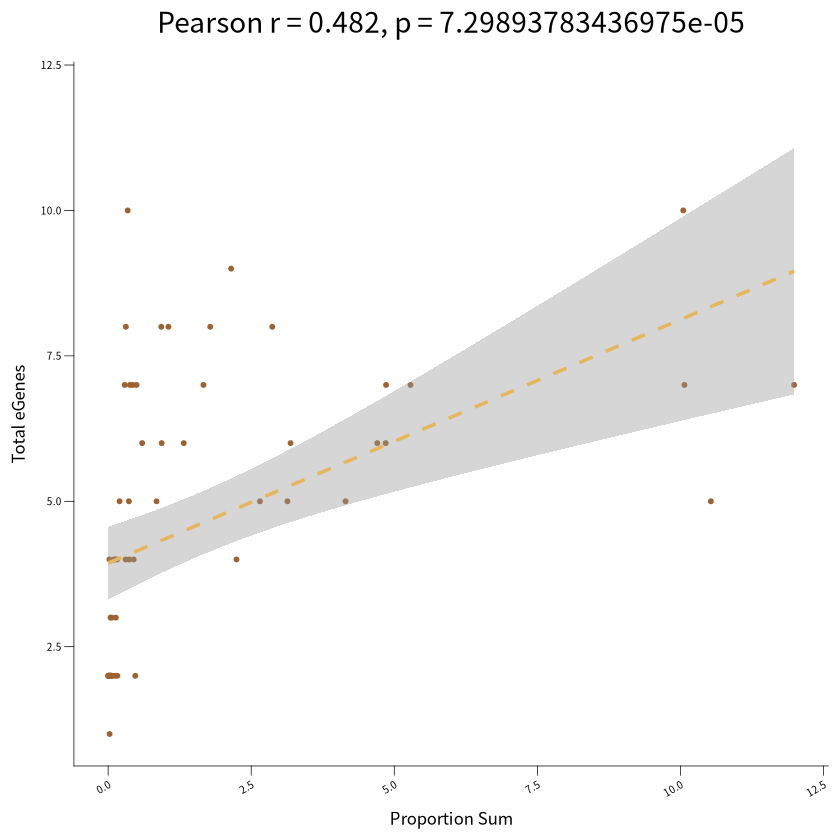

In [101]:
cor_test <- cor.test(merged_data1$total_egenes,
                     merged_data1$Mean,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(merged_data1, aes(x = Mean, y = total_egenes)) +
     geom_point(size=1,color = "#9E6231") +
     geom_smooth(method = "lm", se = T, color = "#E5B65B", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/pQTL_cor_cellratio1.pdf",p,width=3,height=3.5)

In [102]:
merged_data2 <- subset(merged_data, celltype %in% c('Core mature neutrophils','IRF1- GBP2- mature neutrophils','FOS- mature neutrophils','RGS2- mature neutrophils','MMElo pre-mature neutrophils','CXCR4- CXCL8- mature neutrophils',
                                                    'Basophils'))
merged_data2

,celltype,unique_egenes,shared_egenes,total_egenes,Mean
,<chr>,<int>,<int>,<int>,<dbl>
4,Basophils,0,2,2,0.198314
24,CXCR4- CXCL8- mature neutrophils,0,3,3,7.833494
26,Core mature neutrophils,0,3,3,52.599768
28,FOS- mature neutrophils,0,3,3,10.288992
42,IRF1- GBP2- mature neutrophils,0,3,3,15.868853
47,MMElo pre-mature neutrophils,0,4,4,5.364519
65,RGS2- mature neutrophils,0,2,2,7.846611


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


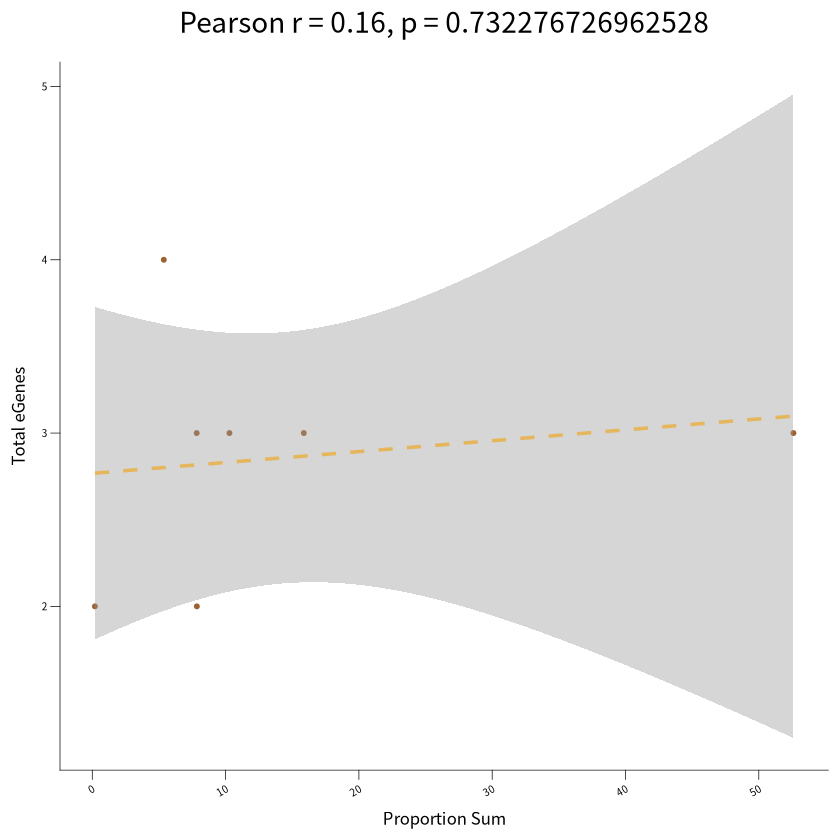

In [103]:
cor_test <- cor.test(merged_data2$total_egenes,
                     merged_data2$Mean,
                     method = "pearson")

cor_val <- round(cor_test$estimate, 3)
p_val <- cor_test$p.value

p <- ggplot(merged_data2, aes(x = Mean, y = total_egenes)) +
     geom_point(size=1,color = "#9E6231") +
     geom_smooth(method = "lm", se = T, color = "#E5B65B", linetype=2) +
     labs(x = "Proportion Sum", y = "Total eGenes", title = paste0("Pearson r = ", cor_val, ", p = ", p_val)) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/pQTL_cor_cellratio2.pdf",p,width=3,height=3.5)

#### plot3

In [104]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/pQTL_all_lead_perm_qvalues.csv",check.names = F,header = T))

In [105]:
subdata <- subset(data,study_wise_qval < 0.05)
subdata <- subdata[,-c(1)]
subdata

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,⋯,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval,study_wise_qval,study_wise_nominal_threshold
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,TNFRSF18,2817,1.049145,175.67972,696.8889,2.201904e-10,1:1217733:G:A,14224,11141,395,⋯,0.2688297,3.209596e-12,-0.13807149,0.01952284,0.00009999,1.636577e-08,Adaptive NK cells,0.000659934,2.568024e-07,7.420554e-05
2,TNFRSF4,2829,1.047612,197.72368,712.7945,4.462068e-05,1:1649976:G:A,438649,435823,387,⋯,0.2520278,9.349625e-06,-0.05573715,0.01249974,0.00589941,6.867978e-03,Adaptive NK cells,0.021631170,3.741960e-02,6.546994e-05
3,TNFRSF9,1680,1.039766,109.49462,696.5448,2.875247e-09,1:7890976:C:G,-24896,-52189,624,⋯,0.4739281,6.942839e-11,0.08660356,0.01310719,0.00009999,1.706374e-07,Adaptive NK cells,0.000659934,2.292037e-06,1.139827e-04
7,CD8A,1832,1.017847,47.30919,672.7690,1.667638e-04,2:85937145:A:T,-847466,-871251,236,⋯,0.1477404,2.588490e-05,-0.14355183,0.03393284,0.00569943,7.154638e-03,Adaptive NK cells,0.021631170,3.818590e-02,2.375969e-04
8,CD8B,1769,1.004540,42.89640,676.6261,1.597111e-04,2:85937145:A:T,-878195,-924779,236,⋯,0.1477404,2.588490e-05,-0.14355183,0.03393284,0.00529947,6.662874e-03,Adaptive NK cells,0.021631170,3.681340e-02,2.454481e-04
17,HLA-DRA,13631,1.057797,198.72008,625.1773,6.820233e-09,6:32693361:A:C,253481,248314,282,⋯,0.1778679,1.838922e-11,0.17340337,0.02545703,0.00009999,6.051806e-07,Adaptive NK cells,0.000659934,7.361358e-06,6.824544e-05
18,HLA-DRB1,13115,1.058529,189.79187,623.9265,7.060164e-09,6:32693361:A:C,115457,103512,282,⋯,0.1778679,1.838922e-11,0.17340337,0.02545703,0.00009999,5.918415e-07,Adaptive NK cells,0.000659934,7.255346e-06,7.169265e-05
20,IL2RA,2831,1.042796,209.17833,717.1782,1.218728e-06,10:6015268:T:G,4578,-47102,461,⋯,0.3192352,1.505046e-07,-0.10776024,0.02034383,0.00009999,1.755941e-04,Adaptive NK cells,0.000659934,1.412986e-03,6.052033e-05
29,IGHD,3519,1.025616,131.82237,694.9921,8.356124e-05,14:105703800:T:G,-132966,-141877,591,⋯,0.4414832,1.523988e-05,-0.06025953,0.01385056,0.00939906,9.653516e-03,Adaptive NK cells,0.031016898,4.793592e-02,8.854634e-05


In [106]:
# 每个 phenotype_id 出现在哪些 celltype
phenotype_counts <- subdata %>%
  group_by(celltype) %>%
  summarise(n_phenotypes = n_distinct(phenotype_id)) %>%
  arrange(desc(n_phenotypes))
phenotype_counts

celltype,n_phenotypes
<chr>,<int>
Th1_Th17,12
Adaptive NK cells,10
CD27- Th17,10
CD27+ Th17,9
CD56bright NK cells,8
GZMK+ CD8+ Tem,8
Memory CD4+ Treg,8
Non-switched memory B cells,8
vNKT,8


In [107]:
phenotype_counts$celltype <- factor(phenotype_counts$celltype,levels = c('Th1_Th17','Adaptive NK cells','CD27- Th17','CD27+ Th17','CD56bright NK cells','GZMK+ CD8+ Tem','Memory CD4+ Treg','Non-switched memory B cells','vNKT','CD1C+ cDC2','CD27+ Th1','CD56dim NK cells','CD8+ Temra','GBP1+ classical monocytes','Naïve CD4+ T cells','Tfh','Th2','Th22','GZMB+ CD8+ Tem','GZMK+ Vδ2+ T cells','HLA-DRhi CD8+ Tem','Intermediate monocytes','Naïve CD8+ T cells','Switched Memory B cells','CD14+ cDC2','CD27+ MAIT','CD27- Th1','Core classical monocytes','GZMB+ CD4+ terminal effector T cells','GZMB+ Vδ2+ T cells','Naïve B cells','ASDC','CD27+ IgD+ atypical memory B cells','Early memory B cells','MMElo pre-mature neutrophils','Naïve CD4+ Treg','Non-classical monocytes','Proliferative NK cells','Proliferative help memory T cells','pDCs','CCR4- CD8+ Tcm','CD27- IgD- atypical memory B cells','CXCR4- CXCL8- mature neutrophils','Core mature neutrophils','FOS- mature neutrophils','ILCP','IRF1- GBP2- mature neutrophils','Atypical naïve B cells','Basophils','CCR4+ CD8+ Tcm','CD27+ IgD- atypical memory B cells','CD62Lhi GZMK+ Vδ2+ T cells','CD95 memory B cells','CILCP','CLP','HLA-DRhi CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','HSC_MPP','IGKChi Plasma cells','IGLL5hi Plasma cells','ISG+ classical monocytes','MC_MCP','MEP','MkP','PADI4+ CD177+ MMP9+ immature neutrophils','Plamsablasts','Platelets','Proliferative CD4+ Treg','Proliferative CD8+ memory T cells','Proliferative DN T cells','RGS2- mature neutrophils',
                                               'MPO+ mature neutrophils'))

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”


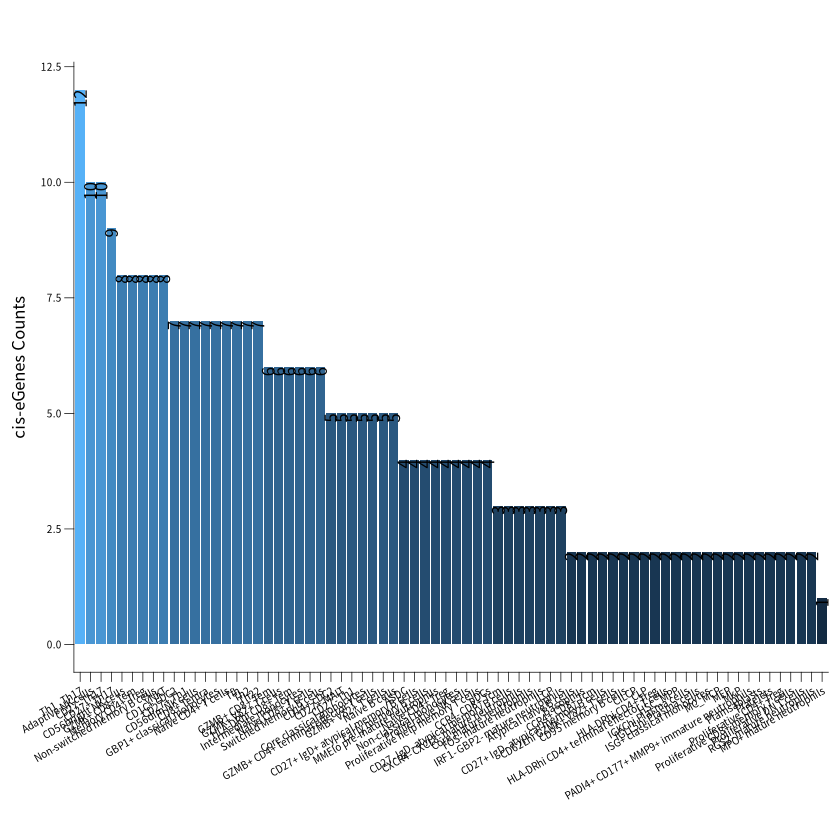

In [109]:
p <- ggplot(phenotype_counts, aes(x = celltype, y = n_phenotypes, fill = n_phenotypes)) +
     geom_bar(stat = "identity") +
     labs(title = "",x = "", y = "cis-eGenes Counts", fill = "Phenotype Type") +
     geom_text(aes(label = n_phenotypes), size = 3.5,angle = 90, hjust = 1) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/celltype_count.pdf",p,width=15,height=3)

#### plot4

In [110]:
# 设置目录
input_dir <- '/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/scADT-seq/02.normal_dis/'

# 获取所有csv文件路径
csv_files <- list.files(input_dir, pattern = "\\.csv$", full.names = TRUE)

# 初始化结果列表
result_list <- lapply(csv_files, function(file) {
  df <- read.csv(file, header = TRUE)
  sample_count <- nrow(df)
  data.frame(
    file_name = tools::file_path_sans_ext(basename(file)),
    sample_count = sample_count
  )
})

# 合并为一个dataframe
result_df <- do.call(rbind, result_list)
result_df

file_name,sample_count
<chr>,<int>
Adaptive NK cells,863
ASDC,829
Atypical naïve B cells,841
Basophils,845
CCR4- CD8+ Tcm,861
CCR4+ CD8+ Tcm,863
CD14+ cDC2,863
CD1C+ cDC2,863
CD27- IgD- atypical memory B cells,855


In [113]:
result_df <- subset(result_df, file_name %in% c('Th1_Th17','Adaptive NK cells','CD27- Th17','CD27+ Th17','CD56bright NK cells','GZMK+ CD8+ Tem','Memory CD4+ Treg','Non-switched memory B cells','vNKT','CD1C+ cDC2','CD27+ Th1','CD56dim NK cells','CD8+ Temra','GBP1+ classical monocytes','Naïve CD4+ T cells','Tfh','Th2','Th22','GZMB+ CD8+ Tem','GZMK+ Vδ2+ T cells','HLA-DRhi CD8+ Tem','Intermediate monocytes','Naïve CD8+ T cells','Switched Memory B cells','CD14+ cDC2','CD27+ MAIT','CD27- Th1','Core classical monocytes','GZMB+ CD4+ terminal effector T cells','GZMB+ Vδ2+ T cells','Naïve B cells','ASDC','CD27+ IgD+ atypical memory B cells','Early memory B cells','MMElo pre-mature neutrophils','Naïve CD4+ Treg','Non-classical monocytes','Proliferative NK cells','Proliferative help memory T cells','pDCs','CCR4- CD8+ Tcm','CD27- IgD- atypical memory B cells','CXCR4- CXCL8- mature neutrophils','Core mature neutrophils','FOS- mature neutrophils','ILCP','IRF1- GBP2- mature neutrophils','Atypical naïve B cells','Basophils','CCR4+ CD8+ Tcm','CD27+ IgD- atypical memory B cells','CD62Lhi GZMK+ Vδ2+ T cells','CD95 memory B cells','CILCP','CLP','HLA-DRhi CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','HSC_MPP','IGKChi Plasma cells','IGLL5hi Plasma cells','ISG+ classical monocytes','MC_MCP','MEP','MkP','PADI4+ CD177+ MMP9+ immature neutrophils','Plamsablasts','Platelets','Proliferative CD4+ Treg','Proliferative CD8+ memory T cells','Proliferative DN T cells','RGS2- mature neutrophils',
                                               'MPO+ mature neutrophils'))
result_df$file_name <- factor(result_df$file_name,levels = c('Th1_Th17','Adaptive NK cells','CD27- Th17','CD27+ Th17','CD56bright NK cells','GZMK+ CD8+ Tem','Memory CD4+ Treg','Non-switched memory B cells','vNKT','CD1C+ cDC2','CD27+ Th1','CD56dim NK cells','CD8+ Temra','GBP1+ classical monocytes','Naïve CD4+ T cells','Tfh','Th2','Th22','GZMB+ CD8+ Tem','GZMK+ Vδ2+ T cells','HLA-DRhi CD8+ Tem','Intermediate monocytes','Naïve CD8+ T cells','Switched Memory B cells','CD14+ cDC2','CD27+ MAIT','CD27- Th1','Core classical monocytes','GZMB+ CD4+ terminal effector T cells','GZMB+ Vδ2+ T cells','Naïve B cells','ASDC','CD27+ IgD+ atypical memory B cells','Early memory B cells','MMElo pre-mature neutrophils','Naïve CD4+ Treg','Non-classical monocytes','Proliferative NK cells','Proliferative help memory T cells','pDCs','CCR4- CD8+ Tcm','CD27- IgD- atypical memory B cells','CXCR4- CXCL8- mature neutrophils','Core mature neutrophils','FOS- mature neutrophils','ILCP','IRF1- GBP2- mature neutrophils','Atypical naïve B cells','Basophils','CCR4+ CD8+ Tcm','CD27+ IgD- atypical memory B cells','CD62Lhi GZMK+ Vδ2+ T cells','CD95 memory B cells','CILCP','CLP','HLA-DRhi CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','HSC_MPP','IGKChi Plasma cells','IGLL5hi Plasma cells','ISG+ classical monocytes','MC_MCP','MEP','MkP','PADI4+ CD177+ MMP9+ immature neutrophils','Plamsablasts','Platelets','Proliferative CD4+ Treg','Proliferative CD8+ memory T cells','Proliferative DN T cells','RGS2- mature neutrophils',
                                               'MPO+ mature neutrophils'))
result_df

,file_name,sample_count
,<fct>,<int>
1,Adaptive NK cells,863
2,ASDC,829
3,Atypical naïve B cells,841
4,Basophils,845
5,CCR4- CD8+ Tcm,861
6,CCR4+ CD8+ Tcm,863
7,CD14+ cDC2,863
8,CD1C+ cDC2,863
9,CD27- IgD- atypical memory B cells,855


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”


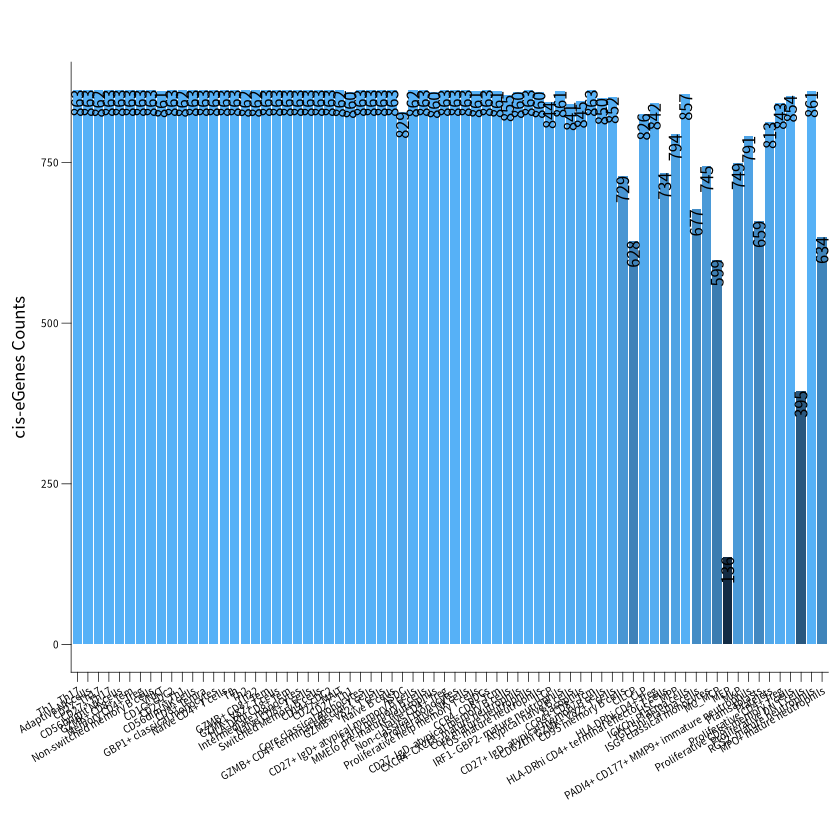

In [114]:
p <- ggplot(result_df, aes(x = file_name, y = sample_count, fill = sample_count)) +
     geom_bar(stat = "identity") +
     labs(title = "",x = "", y = "cis-eGenes Counts", fill = "Phenotype Type") +
     geom_text(aes(label = sample_count), size = 3.5,angle = 90, hjust = 1) +
     mytheme
p
ggsave("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/sample_count.pdf",p,width=15,height=3)

### pQTL

In [1]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL_all_lead_perm_qvalue.csv",check.names = F,header = T))
data

,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,ma_count,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval
<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
0,TNFRSF9,2931,1.0372465,244.12580,665.9110,3.415041e-11,1:7930307:G:A,14435,-12858,508,633,0.3736718,7.579449e-13,0.08094802,0.011102731,0.00009999,4.102973e-09,bulk,0.0002749725
1,TGFA,4200,1.0458522,215.28009,657.2381,2.567994e-03,2:71162435:A:G,715150,608242,252,275,0.1623377,1.027633e-03,-0.05594165,0.016976189,0.41195880,4.029633e-01,bulk,0.5726302370
2,STAMBP,2376,1.0274295,120.31133,669.7665,6.564908e-03,2:73851587:G:T,22670,-22072,504,611,0.3606848,3.372383e-03,-0.02036681,0.006925986,0.54134587,5.344444e-01,bulk,0.6774907415
3,CD8A,2274,1.0360278,122.80860,659.0159,7.946111e-05,2:86718032:A:G,-66579,-90364,200,214,0.1263282,1.782915e-05,0.14979157,0.034695294,0.00689931,8.092419e-03,bulk,0.0168649802
4,IL18R1,3338,1.0453192,137.80128,644.5821,4.551357e-48,2:102368964:A:G,57434,-29813,616,798,0.4710744,1.002602e-57,0.36996415,0.021219919,0.00009999,5.499434e-48,bulk,0.0002749725
5,CASP8,2524,1.0475308,149.49203,642.1708,7.857174e-04,2:201511863:A:C,278419,150027,330,358,0.2113341,2.168814e-04,-0.04161911,0.011200000,0.09369063,9.795340e-02,bulk,0.1627258327
6,CCL20,4215,1.0484973,228.03105,662.3561,2.936719e-03,2:227129527:G:A,-676213,-688037,548,677,0.3996458,1.256450e-03,-0.07372296,0.022770923,0.47025297,4.653752e-01,bulk,0.6207339266
7,DNER,4126,1.0293754,262.59010,675.7734,4.202123e-03,2:230674508:C:A,1316878,959953,523,650,0.3837072,2.114971e-03,0.05191748,0.016834842,0.66133387,6.570563e-01,bulk,0.7604032700
8,CDCP1,2437,1.0181991,116.83399,659.8063,7.122759e-05,3:45129013:G:A,46735,-17409,250,276,0.1629280,1.586707e-05,0.08610874,0.019824108,0.00739926,7.537155e-03,bulk,0.0174411130


In [2]:
sub_data <- subset(data, celltype_level_qval < 0.05)
sub_data

,,phenotype_id,num_var,beta_shape1,beta_shape2,true_df,pval_true_df,variant_id,start_distance,end_distance,ma_samples,ma_count,af,pval_nominal,slope,slope_se,pval_perm,pval_beta,celltype,celltype_level_qval
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,0,TNFRSF9,2931,1.037246,244.1258,665.9110,3.415041e-11,1:7930307:G:A,14435,-12858,508,633,0.3736718,7.579449e-13,0.08094802,0.01110273,0.00009999,4.102973e-09,bulk,0.0002749725
4,3,CD8A,2274,1.036028,122.8086,659.0159,7.946111e-05,2:86718032:A:G,-66579,-90364,200,214,0.1263282,1.782915e-05,0.14979157,0.03469529,0.00689931,8.092419e-03,bulk,0.0168649802
5,4,IL18R1,3338,1.045319,137.8013,644.5821,4.551357e-48,2:102368964:A:G,57434,-29813,616,798,0.4710744,1.002602e-57,0.36996415,0.02121992,0.00009999,5.499434e-48,bulk,0.0002749725
9,8,CDCP1,2437,1.018199,116.8340,659.8063,7.122759e-05,3:45129013:G:A,46735,-17409,250,276,0.1629280,1.586707e-05,0.08610874,0.01982411,0.00739926,7.537155e-03,bulk,0.0174411130
11,10,CXCL8,2868,1.021759,109.0352,662.3560,3.917839e-10,4:73834715:C:T,94195,90999,472,569,0.3358914,1.150581e-11,-0.12097882,0.01755836,0.00009999,2.925821e-08,bulk,0.0002749725
12,11,CXCL6,2598,1.026748,114.5643,665.0786,2.448067e-60,4:73838282:C:T,1641,-10782,475,571,0.3370720,2.300038e-70,0.28153104,0.01429738,0.00009999,8.008106e-60,bulk,0.0002749725
13,12,CXCL1,2486,1.034969,108.3833,657.8411,1.581824e-26,4:73868964:A:G,-430,-2344,218,236,0.1393152,4.127772e-31,0.27494138,0.02267849,0.00009999,2.491862e-25,bulk,0.0002749725
14,13,CXCL5,2219,1.037582,114.5323,670.3232,6.618625e-07,4:73868951:T:C,-126692,-129726,612,813,0.4799292,8.301891e-08,-0.07588930,0.01402237,0.00009999,5.221623e-05,bulk,0.0002749725
20,19,LTA,11523,1.065760,195.0491,579.9120,1.276267e-29,6:31541507:G:C,-30548,-32817,632,827,0.4881936,3.246532e-39,-0.30037647,0.02166933,0.00009999,4.305412e-29,bulk,0.0002749725


In [3]:
length(unique(sub_data$phenotype_id))

[1] 29

In [6]:
write.csv(sub_data,'/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/pQTL_all_lead_perm_qvalues_0.05.csv')

### eQTL小提琴图

In [3]:
phenotype_id <- c('ABCG2')
variantid <- c('4:88143450:C:T')
pval_adj_bh <- c('6.95428242161569e-09')
celltype <- c('Core NDNs')

In [4]:
#变异信息
geno_data <- read_parquet("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/Genetics/WGS_HP_genotype.parquet")
sub_geno_data <- as.data.frame(t(subset(geno_data, variant_id %in% variantid)))
colnames(sub_geno_data) <- sub_geno_data[1,]
sub_geno_data <- sub_geno_data[-1, , drop = FALSE]

In [5]:
for (i in 1:length(phenotype_id)){
    sub_phenotype_id <- phenotype_id[i]
    sub_variant_id <- variantid[i]
    sub_pval_adj_bh <- pval_adj_bh[i]
    sub_celltype <- celltype[i]

    #基因信息
    gene_data <- read.csv(paste0("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Data/scRNA-seq/07.gene_expression_csv/",sub_celltype,".csv"))
    sub_gene_data <- subset(gene_data, gene_id %in% phenotype_id)
    sub_gene_data <- as.data.frame(t(sub_gene_data[,-c(1,2,3)]))
    colnames(sub_gene_data) <- sub_gene_data[1,]
    sub_gene_data <- sub_gene_data[-1, , drop = FALSE]
    rownames(sub_gene_data) <- gsub("\\.", "-", rownames(sub_gene_data))

    #信息合并
    sub_geno_data_tmp <- sub_geno_data[,sub_variant_id,drop = FALSE]
    sub_gene_data_tmp <- sub_gene_data[,sub_phenotype_id,drop = FALSE]
    merged_data <- cbind(sub_gene_data_tmp[intersect(rownames(sub_gene_data_tmp), rownames(sub_gene_data_tmp)), , drop = FALSE],
                         sub_geno_data_tmp[intersect(rownames(sub_gene_data_tmp), rownames(sub_geno_data_tmp)), , drop = FALSE])
    merged_data[[1]] <- as.numeric(merged_data[[1]])
    merged_data[[2]] <- as.numeric(merged_data[[2]])
    merged_data[[2]] <- factor(merged_data[[2]], levels = c("0", "1", "2"))

    #计算中位值
    medians <- merged_data %>%
    group_by(!!sym(names(merged_data)[2])) %>%
    summarize(med = median(.data[[names(merged_data)[1]]], na.rm = TRUE)) %>%
    ungroup()

    #作图
    p <- ggplot(merged_data, aes(x = !!sym(names(merged_data)[2]), y = !!sym(names(merged_data)[1]))) +
         geom_violin(trim = FALSE, scale = "width", fill = "#99C7DB") +
         geom_boxplot(width = 0.1, outlier.size = 0.5, position = position_dodge(0.9)) +
         geom_line(data = medians, aes(x = !!sym(names(medians)[1]), y = med, group = 1), size = 1,color = "#3A6FB0") +
         #geom_jitter(aes(x = !!sym(names(merged_data)[2]), y = !!sym(names(merged_data)[1])), size = 1, 
         #            position = position_jitter(width = 0.15, height = 0), color = "#3A6FB0") +
         labs(title = paste0("P = ",sub_pval_adj_bh,"; Celltype = ",sub_celltype), 
              x = colnames(merged_data)[2], y = colnames(merged_data)[1]) +
         mytheme
    ggsave(paste0('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/cis/',sub_celltype,"_",sub_phenotype_id,"_",sub_variant_id,'.pdf'),p)
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Saving 7 x 7 in image


### pQTL小提琴图

In [6]:
phenotype_id <- c('CCL4','CD40','CD244','IL18R1','TNFSF14')
variantid <- c('17:36100085:C:G','20:46133746:C:T','1:160902873:G:A','2:102332172:A:C','19:6668961:C:T')
pval_adj_bh <- c('4.8200967932294324e-36','1.4450597107624872e-24','9.954523682525226e-10','2.158758963825804e-24','2.9089939484479147e-13')
celltype <- c('bulk','bulk','bulk','bulk','bulk')

In [7]:
#变异信息
geno_data <- read_parquet("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/Genetics/WES_HP_genotype.parquet")
sub_geno_data <- as.data.frame(t(subset(geno_data, variant_id %in% variantid)))
colnames(sub_geno_data) <- sub_geno_data[1,]
sub_geno_data <- sub_geno_data[-1, , drop = FALSE]

In [8]:
for (i in 1:length(phenotype_id)){
    sub_phenotype_id <- phenotype_id[i]
    sub_variant_id <- variantid[i]
    sub_pval_adj_bh <- pval_adj_bh[i]
    sub_celltype <- celltype[i]

    #基因信息
    gene_data <- read.csv(paste0("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Data/Olink/Olink_72.csv"))
    sub_gene_data <- subset(gene_data, gene_id %in% phenotype_id)
    sub_gene_data <- as.data.frame(t(sub_gene_data[,-c(1,2,3,868)]))
    colnames(sub_gene_data) <- sub_gene_data[1,]
    sub_gene_data <- sub_gene_data[-1, , drop = FALSE]
    rownames(sub_gene_data) <- gsub("\\.", "-", rownames(sub_gene_data))

    #信息合并
    sub_geno_data_tmp <- sub_geno_data[,sub_variant_id,drop = FALSE]
    sub_gene_data_tmp <- sub_gene_data[,sub_phenotype_id,drop = FALSE]
    merged_data <- cbind(sub_gene_data_tmp[intersect(rownames(sub_gene_data_tmp), rownames(sub_gene_data_tmp)), , drop = FALSE],
                         sub_geno_data_tmp[intersect(rownames(sub_gene_data_tmp), rownames(sub_geno_data_tmp)), , drop = FALSE])
    merged_data[[1]] <- as.numeric(merged_data[[1]])
    merged_data[[2]] <- as.numeric(merged_data[[2]])
    merged_data[[2]] <- factor(merged_data[[2]], levels = c("0", "1", "2"))

    #计算中位值
    medians <- merged_data %>%
    group_by(!!sym(names(merged_data)[2])) %>%
    summarize(med = median(.data[[names(merged_data)[1]]], na.rm = TRUE)) %>%
    ungroup()

    #作图
    p <- ggplot(merged_data, aes(x = !!sym(names(merged_data)[2]), y = !!sym(names(merged_data)[1]))) +
         geom_violin(trim = FALSE, scale = "width", fill = "#99C7DB") +
         geom_boxplot(width = 0.1, outlier.size = 0.5, position = position_dodge(0.9)) +
         geom_line(data = medians, aes(x = !!sym(names(medians)[1]), y = med, group = 1), size = 1,color = "#3A6FB0") +
         #geom_jitter(aes(x = !!sym(names(merged_data)[2]), y = !!sym(names(merged_data)[1])), size = 1, 
         #            position = position_jitter(width = 0.15, height = 0), color = "#3A6FB0") +
         labs(title = paste0("P = ",sub_pval_adj_bh,"; Celltype = ",sub_celltype), 
              x = colnames(merged_data)[2], y = colnames(merged_data)[1]) +
         mytheme
    ggsave(paste0('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WES/Germline/Result/plot/pQTL/',sub_celltype,"_",sub_phenotype_id,"_",sub_variant_id,'.pdf'),p)
}

Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image


### rb计算

In [3]:
data <- as.data.frame(read.csv("/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/eQTL_all_lead_perm_qvalues_0.05.csv",check.names = F,header = T))
data <- data[,c('phenotype_id','variant_id','slope','slope_se','celltype')]
data

phenotype_id,variant_id,slope,slope_se,celltype
<chr>,<chr>,<dbl>,<dbl>,<chr>
LINC01409,1:913469:G:C,0.3765205,0.07683704,Adaptive NK cells
LINC00115,1:913469:G:C,0.7540356,0.07656465,Adaptive NK cells
LINC01128,1:913469:G:C,0.9652224,0.06992146,Adaptive NK cells
PLEKHN1,1:967724:C:T,0.2515789,0.05227502,Adaptive NK cells
HES4,1:1000079:A:G,0.5806572,0.06369613,Adaptive NK cells
ISG15,1:1015903:C:T,0.1901433,0.03046918,Adaptive NK cells
C1orf159,1:1023789:G:C,-0.2388179,0.05676469,Adaptive NK cells
TNFRSF18,1:1217733:G:A,-0.7218388,0.03988647,Adaptive NK cells
TNFRSF4,1:1217251:C:A,-0.6538712,0.03936067,Adaptive NK cells


In [4]:
celltype_list <- split(data, data$celltype)
data

phenotype_id,variant_id,slope,slope_se,celltype
<chr>,<chr>,<dbl>,<dbl>,<chr>
LINC01409,1:913469:G:C,0.3765205,0.07683704,Adaptive NK cells
LINC00115,1:913469:G:C,0.7540356,0.07656465,Adaptive NK cells
LINC01128,1:913469:G:C,0.9652224,0.06992146,Adaptive NK cells
PLEKHN1,1:967724:C:T,0.2515789,0.05227502,Adaptive NK cells
HES4,1:1000079:A:G,0.5806572,0.06369613,Adaptive NK cells
ISG15,1:1015903:C:T,0.1901433,0.03046918,Adaptive NK cells
C1orf159,1:1023789:G:C,-0.2388179,0.05676469,Adaptive NK cells
TNFRSF18,1:1217733:G:A,-0.7218388,0.03988647,Adaptive NK cells
TNFRSF4,1:1217251:C:A,-0.6538712,0.03936067,Adaptive NK cells


In [5]:
compute_rb <- function(df_ref, df_query){
    merged <- inner_join(df_ref, df_query, by = "phenotype_id", suffix = c("_ref","_query"))

    weighted_cov <- function(x, y, w){w <- w / sum(w)
                                      cov_xy <- sum(w * (x - sum(w * x)) * (y - sum(w * y)))
                                      return(cov_xy)}
    weighted_var <- function(x, w){return(weighted_cov(x, x, w))}
    
    w <- 1 / (merged$slope_se_ref^2 + merged$slope_se_query^2)

    cov_xy <- weighted_cov(merged$slope_ref, merged$slope_query, w)
    var_x  <- weighted_var(merged$slope_ref, w)
    var_y  <- weighted_var(merged$slope_query, w)
    rb <- cov_xy / sqrt(var_x * var_y)
    return(rb)
}

In [6]:
celltypes <- names(celltype_list)
rb_matrix <- matrix(NA, nrow=length(celltypes), ncol=length(celltypes),
                    dimnames = list(celltypes, celltypes))

for(i in seq_along(celltypes)){
  for(j in seq_along(celltypes)){
    # 过滤 eGene 数量
    if(length(unique(celltype_list[[celltypes[i]]]$phenotype_id)) >= 30 &
       length(unique(celltype_list[[celltypes[j]]]$phenotype_id)) >= 30){
      
      rb_matrix[i,j] <- compute_rb(celltype_list[[celltypes[i]]],
                                   celltype_list[[celltypes[j]]])
    }
  }
}
rb_matrix

,Adaptive NK cells,ALPL- MARCKS- NDNs,ASDC,Atypical naïve B cells,Basophils,CCR4- CD8+ Tcm,CCR4+ CD8+ Tcm,CD14+ cDC2,CD177int iLDNs,CD1C+ cDC2,⋯,Proliferative Vδ2+ T cells,RGS2- NDNs,SOX4+ Vδ1+ T cells,Switched Memory B cells,Tfh,Th1_Th17,Th2,Th22,VIM- FLNA- NDNs,vNKT
Adaptive NK cells,1.0000000,0.5110903,0.6316296,0.4448441,0.6064272,0.6373767,0.7188253,0.6152053,0.5884376,0.6200241,⋯,NA,0.5076106,NA,0.6450644,0.7228853,0.7585475,0.6994814,0.6840593,0.5114678,0.8304929
ALPL- MARCKS- NDNs,0.5110903,1.0000000,0.4166597,0.2789715,0.4877373,0.5856047,0.5435177,0.5907542,0.2991364,0.5492082,⋯,NA,0.9408855,NA,0.5001167,0.5206449,0.5372209,0.4990193,0.5391051,0.9342004,0.5197373
ASDC,0.6316296,0.4166597,1.0000000,0.4956511,0.4708656,0.6429272,0.6812558,0.7864375,0.8335921,0.7157932,⋯,NA,0.3727765,NA,0.6707877,0.5581915,0.6280179,0.6338844,0.4642803,0.4299016,0.7783843
Atypical naïve B cells,0.4448441,0.2789715,0.4956511,1.0000000,0.9204455,0.7431096,0.7226793,0.5601298,0.6704475,0.5241287,⋯,NA,0.3273211,NA,0.7423711,0.5267817,0.6293701,0.8705021,0.7772915,0.3676097,0.6688341
Basophils,0.6064272,0.4877373,0.4708656,0.9204455,1.0000000,0.6018573,0.6837478,0.6857198,0.5779990,0.6764295,⋯,NA,0.5515843,NA,0.7419739,0.6523633,0.6297907,0.7030390,0.6431066,0.5964366,0.6452231
CCR4- CD8+ Tcm,0.6373767,0.5856047,0.6429272,0.7431096,0.6018573,1.0000000,0.8224006,0.6409894,0.3356638,0.6735393,⋯,NA,0.6079842,NA,0.7140037,0.7195025,0.7722585,0.7845521,0.8019464,0.6188280,0.7670128
CCR4+ CD8+ Tcm,0.7188253,0.5435177,0.6812558,0.7226793,0.6837478,0.8224006,1.0000000,0.6687932,0.6185918,0.6788914,⋯,NA,0.5478329,NA,0.7633262,0.8264146,0.8469769,0.8525753,0.8548219,0.5450945,0.7971446
CD14+ cDC2,0.6152053,0.5907542,0.7864375,0.5601298,0.6857198,0.6409894,0.6687932,1.0000000,0.8153261,0.8414257,⋯,NA,0.5854890,NA,0.6712842,0.6148492,0.6360682,0.6224702,0.5723136,0.5927599,0.6924653
CD177int iLDNs,0.5884376,0.2991364,0.8335921,0.6704475,0.5779990,0.3356638,0.6185918,0.8153261,1.0000000,0.6280202,⋯,NA,0.1972579,NA,0.6644555,0.5634117,0.5185374,0.7113108,0.4614852,0.2740612,0.7102413
CD1C+ cDC2,0.6200241,0.5492082,0.7157932,0.5241287,0.6764295,0.6735393,0.6788914,0.8414257,0.6280202,1.0000000,⋯,NA,0.5519347,NA,0.6742095,0.6120206,0.6388107,0.6545949,0.5891143,0.5682501,0.6523272


In [7]:
selected_ct <- c('Core NDNs','MT-ATP6- MT-CO2- NDNs','ALPL- MARCKS- NDNs','IRF1- GBP2- NDNs','RGS2- NDNs','VIM- FLNA- NDNs','FOS- NDNs','CXCL8- PTGS2+ NDNs','IFIT2- RNF213- NDNs','Basophils','MMP8+ CD177+ iLDNs','Proliferative iLDNs','MMP8+ CD177+ mLDNs','MMP9+ CD177+ iLDNs','MPO+ CD177- iLDNs','CD177int iLDNs','MPO- CD177- iLDNs','MPO+ mLDNs')

In [8]:
rb_matrix_selected <- rb_matrix[selected_ct, selected_ct, drop = FALSE]
rb_matrix_selected <- rb_matrix[selected_ct, selected_ct, drop = FALSE]
rb_matrix_selected <- rb_matrix_selected[
  rowSums(is.na(rb_matrix_selected)) < ncol(rb_matrix_selected),   # 非全 NA 行
  colSums(is.na(rb_matrix_selected)) < nrow(rb_matrix_selected)    # 非全 NA 列
]

In [9]:
mean(rb_matrix_selected)

[1] 0.5745384

Saving 7 x 7 in image


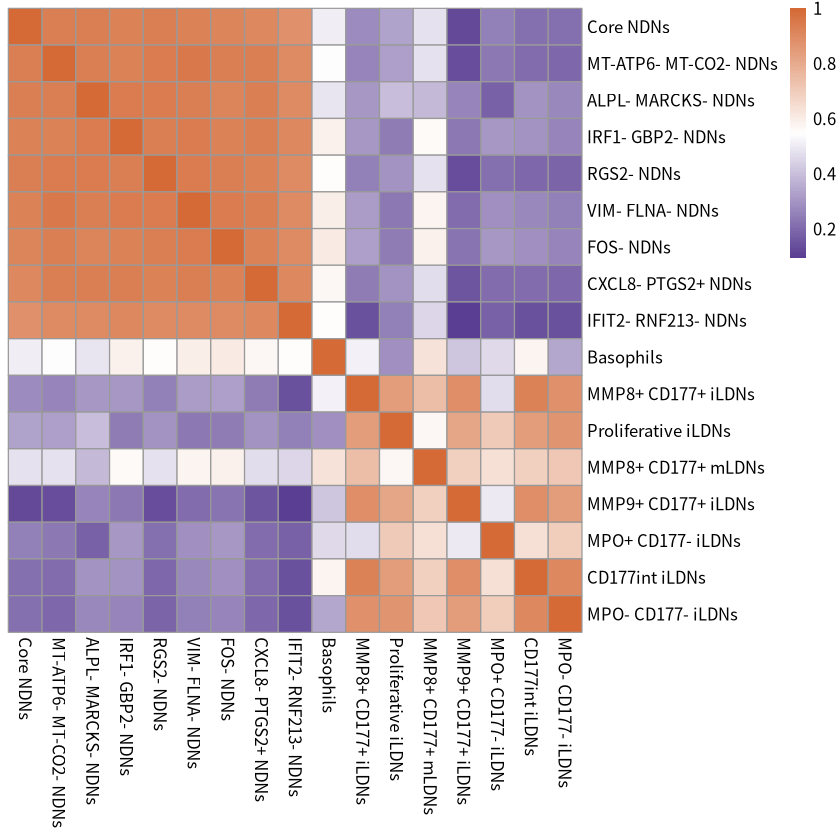

In [10]:
library(pheatmap)
p <- pheatmap(abs(rb_matrix_selected),
         cluster_rows = F,
         cluster_cols = F,
         color = colorRampPalette(c("#5A3E93","white","#D56A37"))(100))
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/rb1.pdf',p)

In [11]:
selected_ct <- c('Naïve CD4+ T cells','Tfh','CD27+ Th17','Th1_Th17','Memory CD4+ Treg','GZMB+ CD4+ terminal effector T cells','CD27+ Th1','Th2','CD27- Th17','Th22','Naïve CD4+ Treg','KLRB1+ CD4+ Treg','Proliferative help memory T cells','CD27- Th1','HLA-DRhi CD4+ Treg','Proliferative CD4+ Treg','HLA-DRhi CD4+ terminal effector T cells','CD4+ Temra','Proliferative cytotoxic CD4+ T cells','GZMK+ CD8+ Tem','CD8+ Temra','HLA-DRhi CD8+ Tem','GZMB+ CD8+ Tem','Naïve CD8+ T cells','GZMB+ Vδ2+ T cells','GZMK+ Vδ2+ T cells','CCR4+ CD8+ Tcm','CD27+ MAIT','vNKT','CCR4- CD8+ Tcm','CD62Lhi GZMK+ Vδ2+ T cells','Proliferative CD8+ memory T cells','CD27- MAIT','DN T cells','Naïve Vδ1+ T cells','GZMK+ effector Vδ1+ T cells','CD279+ SOX4+ Vδ1+ T cells','CD8+ Treg','Proliferative DN T cells','KLRC2+ effector Vδ1+ T cells','Proliferative Vδ2+ T cells','SOX4+ Vδ1+ T cells','iNKT','CD56+ MAIT','CD56dim NK cells','Adaptive NK cells','CD56bright NK cells','Proliferative NK cells','CLP','ILCP','ILC2','CILCP','Naïve B cells','Non-switched memory B cells','Switched Memory B cells','Early memory B cells','IGKChi Plasma cells','CD27+ IgD+ atypical memory B cells','CD27- IgD- atypical memory B cells','CD27+ IgD- atypical memory B cells','Atypical naïve B cells','Plamsablasts','IGLL5hi Plasma cells','CD95 memory B cells','Core classical monocytes','Non-classical monocytes','Intermediate monocytes','GBP1+ classical monocytes','CD1C+ cDC2','CD14+ cDC2','pDCs','cDC1','ASDC','HSC_MPP','ISG+ classical monocytes','MkP','Platelets','MC_MCP','MEP',
                 'LAMP3+ DC')

In [12]:
rb_matrix_selected <- rb_matrix[selected_ct, selected_ct, drop = FALSE]
rb_matrix_selected <- rb_matrix_selected[
  rowSums(is.na(rb_matrix_selected)) < ncol(rb_matrix_selected),   # 非全 NA 行
  colSums(is.na(rb_matrix_selected)) < nrow(rb_matrix_selected)    # 非全 NA 列
]

In [13]:
mean(rb_matrix_selected)

[1] 0.7062476

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Naïve Vδ1+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in g

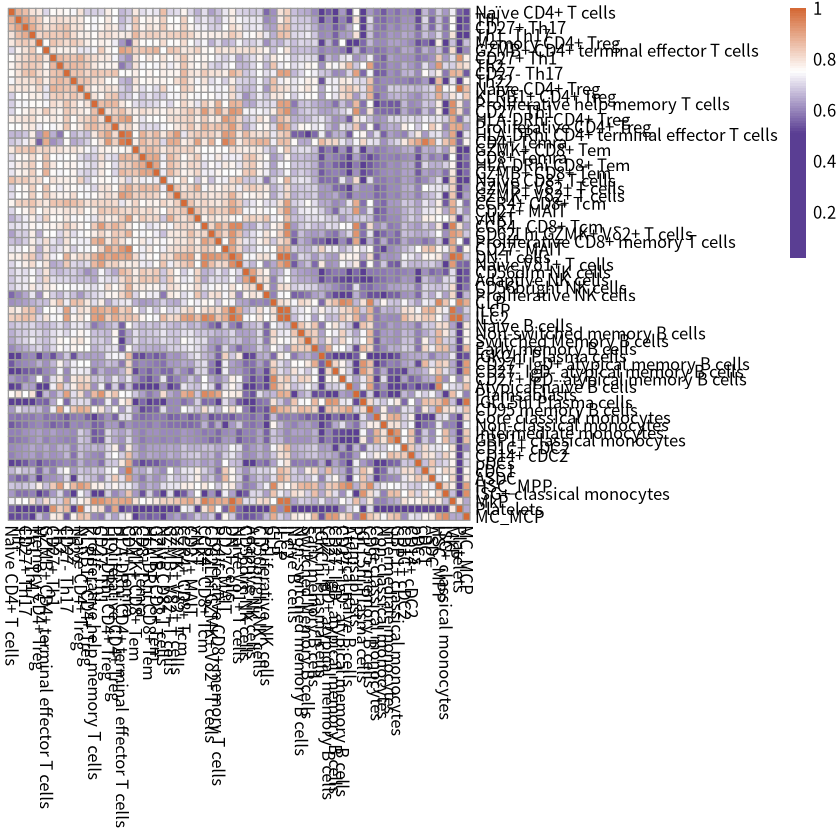

In [14]:
p <- pheatmap(abs(rb_matrix_selected),
         cluster_rows = F,
         cluster_cols = F,
         color = colorRampPalette(c("#5A3E93",'#5A3E93',"#5A3E93","white","#D56A37"))(100))
ggsave('/media/AnalysisDisk2/Yangshichen/2_My-Onek/WGS/Result/plot/rb2.pdf',p, width=15,height=15)